# 실적발표의 인과효과 분석 — IT 섹터 (DiD)

이 노트북 하나로 **데이터 수집부터 결과 정리까지** 전부 진행합니다.

다른 섹터를 분석하실 때는 **3번 "설정" 셀만 바꾸시면** 같은 방식으로 돌아갑니다.

---

## 이 노트북이 답하려는 질문 두 가지

**질문 1. 실적을 발표하면, 주가와 거래량이 얼마나 달라지나요?** → 이하 **"발표 효과 분석"**
- 실적을 발표한 회사와, 같은 시기에 발표하지 않은 회사를 비교합니다.

**질문 2. 서프라이즈가 클수록 주가가 더 오르나요?** → 이하 **"서프라이즈 크기 분석"**
- 실적을 발표한 회사들끼리, 서프라이즈 크기에 따라 주가 반응이 얼마나 달라지는지 봅니다.

---

## 목차

1. 작업 폴더 설정
2. 라이브러리 준비
3. 설정 (섹터, 기간, 규칙)
4. 실험 설계 한눈에 보기
5. 용어 사전
6. 데이터 수집 ① 회사 목록
7. 데이터 수집 ② 주가·거래량
8. 데이터 수집 ③ 실적발표 기록
9. 데이터 정리: 반응일 정하기, 회사 기준 서프라이즈 점수 계산
10. 데이터 점검
11. 발표 효과 분석
12. 서프라이즈 크기 분석
13. 검증 (결과를 믿을 수 있는지)
14. 최종 요약과 결과 저장
15. 한계와 주의할 점

## 1. 작업 폴더 설정

결과 파일(표, 그래프)이 저장될 위치를 정합니다.

- **코랩(Colab)을 쓰시는 경우**: 코랩은 런타임이 끝나면 파일이 지워집니다. 결과를 남기시려면 `USE_DRIVE = True`로 바꾸고 실행하세요. 구글 드라이브의 `DRIVE_FOLDER`에 저장됩니다. (실행하면 구글 계정 접근 허용 창이 뜹니다)
- **내 컴퓨터에서 쓰시는 경우**: 그대로 두시면 이 노트북이 있는 폴더에 저장됩니다.

In [1]:
USE_DRIVE = False
DRIVE_FOLDER = "/content/drive/MyDrive/did_pilot"

if USE_DRIVE:
    import os
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
    os.chdir(DRIVE_FOLDER)
    print("작업 폴더:", os.getcwd())

## 2. 라이브러리 준비

처음 한 번만 아래 셀의 `# !pip install ...` 줄에서 `#`을 지우고 실행하세요.

| 라이브러리 | 하는 일 |
|---|---|
| `yfinance` | 야후 파이낸스에서 주가, 거래량, 실적발표 기록을 무료로 가져옵니다 |
| `pyfixest` | DiD 회귀분석을 빠르게 계산해 줍니다 |
| `lxml`, `html5lib`, `beautifulsoup4` | 위키피디아 표(회사 목록)를 읽어 옵니다 |

In [3]:
# !pip install yfinance pyfixest lxml html5lib beautifulsoup4

import time
import warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import yfinance as yf
import pyfixest as pf
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("yfinance", yf.__version__, "/ pyfixest", pf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.2/76.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.8/499.8 kB 26.4 MB/s eta 0:00:00
yfinance 0.2.66 / pyfixest 0.60.0


## 3. 설정 — 다른 섹터를 분석하실 때는 이 셀만 바꾸세요

| 설정 | 현재 값 | 의미 |
|---|---|---|
| `SECTOR_NAME` | IT | 결과 파일 이름에 붙는 섹터 이름 |
| `GICS_SECTOR` | Information Technology | 위키피디아 S&P500 표의 섹터 이름 (GICS 업종 분류 기준) |
| `INCLUDE_KEYWORDS` | (비움) | 세부업종 이름에 이 단어가 **들어간** 회사만 씁니다. 비우면 섹터 전체 |
| `EXCLUDE_KEYWORDS` | Semiconductor | 세부업종 이름에 이 단어가 들어간 회사는 **뺍니다** (반도체는 다른 팀원 담당) |
| `EXCLUDE_TICKERS` | (비움) | 특정 회사를 직접 뺄 때 사용 |
| `N_FIRMS` | 30 | 시가총액 상위 몇 개 회사를 쓸지 |
| `SELECT_BY` | start | 시가총액 순위를 **2022년 초 기준**("start")으로 매길지, **지금 기준**("now")으로 매길지 |
| `EVENT_START` ~ `EVENT_END` | 2022-01-01 ~ 오늘 | 분석할 실적발표 기간 |
| `WIN` | 10 | **대조군 기준 = 분석 구간 = 반응일 앞뒤 10거래일** (팀 결정) |
| `HIST_QUARTERS` | 8 | 회사의 "평소 서프라이즈"를 지난 몇 분기로 계산할지 (팀 결정) |

**다른 섹터 예시**
- 반도체: `INCLUDE_KEYWORDS = ["Semiconductor"]`, `EXCLUDE_KEYWORDS = []`
- 보험: `GICS_SECTOR = "Financials"`, `INCLUDE_KEYWORDS = ["Insurance"]`, `EXCLUDE_TICKERS = ["BRK-B"]` (버크셔해서웨이는 토요일에 발표하고 여러 사업을 가진 지주회사라 제외 권장)

**`SELECT_BY = "start"`를 쓰는 이유**: "지금" 시가총액으로 회사를 고르면, 2022년엔 작았는데 그 사이 크게 성장한 회사만 들어오고 그 사이 부진했던 회사는 빠집니다. 그러면 "잘 된 회사" 위주로 치우칩니다(생존 편향). 그래서 분석 시작 시점(2022년 초) 기준으로 고릅니다. 2022년 초 시가총액은 "지금 시가총액 × (2022년 초 주가 ÷ 지금 주가)"로 근사합니다.

In [4]:
# ===== 섹터 설정 =====
SECTOR_NAME = "IT"
GICS_SECTOR = "Information Technology"
INCLUDE_KEYWORDS = []
EXCLUDE_KEYWORDS = ["Semiconductor"]
EXCLUDE_TICKERS = []
N_FIRMS = 30
SELECT_BY = "start"

# ===== 기간 =====
EVENT_START = "2022-01-01"
EVENT_END = pd.Timestamp.today().strftime("%Y-%m-%d")
PRICE_START = "2021-07-01"        # 발표 60거래일 전부터 "평소 거래량"을 재야 해서 일찍 시작

# ===== 분석 규칙 (팀 결정) =====
WIN = 10                          # 대조군 기준 = 분석 구간 = 반응일 앞뒤 10거래일
HIST_QUARTERS, HIST_MIN = 8, 4    # 평소 서프라이즈 = 지난 8분기 (최소 4분기 있어야 계산)

# ===== 세부 규칙 (아래 설명 참고) =====
BASE_START, BASE_END = 60, 21     # 평소 거래량 기준: 반응일 60 ~ 21거래일 전
SURPRISE_CLIP = 100.0             # 서프라이즈 %는 -100% ~ +100% 사이로 자름 (예상치가 0 근처일 때 폭발 방지)
SCORE_FLOOR = 1.0                 # 회사의 평소 오르내림 폭 최소값 (%p) (0으로 나누는 것 방지)
SCORE_CLIP = 5.0                  # 회사 기준 점수는 -5 ~ +5 사이로 자름 (극단값 방지)
SHOCK = 0.03                      # S&P500이 하루 ±3% 이상이면 "시장 충격일"
PLACEBO_SHIFT = 31                # 가짜 발표일 = 실제 반응일 31거래일(약 45일) 전
N_BOOT = 300                      # 부트스트랩 반복 횟수

# IT 세부업종 묶기 (같은 묶음 = 직접 경쟁 가능성이 큰 회사들). 다른 섹터는 비워두면 GICS 세부업종 그대로 씀
GROUP_MAP = {
    "Application Software": "Software", "Systems Software": "Software",
    "Technology Hardware, Storage & Peripherals": "Hardware & Storage",
    "Communications Equipment": "Comm Equipment & Optical",
    "Electronic Components": "Electronics", "Electronic Equipment & Instruments": "Electronics",
    "Electronic Manufacturing Services": "Electronics", "Technology Distributors": "Electronics",
    "IT Consulting & Other Services": "IT Services", "Internet Services & Infrastructure": "IT Services",
}
GROUP_OVERRIDE = {"COHR": "Comm Equipment & Optical"}   # 광부품 회사라 통신장비 쪽으로

OUT_DIR = Path(f"results_{SECTOR_NAME}")
OUT_DIR.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")

print(f"섹터: {SECTOR_NAME} / 기간: {EVENT_START} ~ {EVENT_END} / 구간: 반응일 ±{WIN}거래일 / 결과 폴더: {OUT_DIR}")

섹터: IT / 기간: 2022-01-01 ~ 2026-10-07 / 구간: 반응일 ±10거래일 / 결과 폴더: results_IT


## 4. 실험 설계 한눈에 보기

### 4-1. 발표 효과 분석

| 항목 | 내용 |
|---|---|
| 질문 | 실적을 발표하면 주가와 거래량이 얼마나 달라지나요? |
| 처치군 (효과를 보고 싶은 쪽) | 실적을 발표한 회사. **발표 1건마다** 따로 실험을 만듭니다 |
| 대조군 (비교 기준) | 그 발표의 반응일 **앞뒤 10거래일 동안 자기 실적발표가 하나도 없는** 같은 섹터 회사들 |
| 보는 구간 | 반응일 10거래일 전 ~ 10거래일 후 (총 21거래일) |
| 결과 (무엇이 달라지나) | ① 주가 흔들림 ② 거래량 ③ 주가 방향 |
| 계산 방법 | Stacked DiD (메인), Callaway–Sant'Anna 방식 (확인용), 단순 회귀 TWFE (비교용) |
| 핵심 숫자 | **반응일에 처치군이 대조군보다 얼마나 더 움직였나** |

**왜 "발표 안 한 회사"를 이렇게 정하나요?**
상장사는 모두 결국 실적을 발표합니다. 그래서 "평생 발표 안 하는 회사"는 없습니다. 대신 "**그 시기에만 잠깐 발표가 없는 회사**"를 비교 기준으로 씁니다. 같은 회사가 이번 실험에선 대조군, 다음 분기 실험에선 처치군이 될 수 있습니다.

### 4-2. 서프라이즈 크기 분석

| 항목 | 내용 |
|---|---|
| 질문 | 서프라이즈가 클수록 주가가 더 오르나요? |
| 대상 | **실적을 발표한 회사들만** (발표하지 않은 회사는 쓰지 않습니다) |
| 서프라이즈 | **회사 기준 점수**를 숫자 그대로 사용 (그룹으로 나누지 않음) |
| 보는 구간 | 반응일 10거래일 전 ~ 10거래일 후 |
| 결과 | 주가 방향 (초과수익률) |
| 핵심 숫자 | **점수가 1 올라갈 때마다 반응일 주가가 몇 %p 더 오르나** (기울기) |

**비유하면**: 발표 효과 분석은 "약을 먹은 사람 vs 안 먹은 사람" 비교이고, 서프라이즈 크기 분석은 "약을 1알, 2알, 3알 먹은 사람끼리 비교해서 **1알 더 먹을 때마다 얼마나 더 좋아지나**"를 보는 것입니다. 그래서 서프라이즈가 작은 발표가 자연스럽게 비교 기준이 됩니다.

### 4-3. 회사 기준 서프라이즈 점수

> **점수 = (이번 서프라이즈 − 그 회사 평소 서프라이즈) ÷ 그 회사가 평소 오르내리는 폭**

- **서프라이즈(%)** = (실제 EPS − 예상 EPS) ÷ 예상 EPS × 100. 예: 예상 1.00달러, 실제 1.10달러 → +10%
- **평소 서프라이즈** = 그 회사의 **지난 8분기** 서프라이즈 평균 (그 발표 **이전** 분기만 사용)
- **평소 오르내리는 폭** = 지난 8분기 서프라이즈의 표준편차 (보통 이 정도 위아래로 다르다는 뜻)

**예시** (가상의 숫자): 회사 X는 지난 8분기 동안 평균 +8%씩 예상을 넘겼고, 보통 ±2%p 정도 오르내렸습니다.

| 이번 서프라이즈 | 계산 | 점수 | 뜻 |
|---|---|---|---|
| +12% | (12 − 8) ÷ 2 | **+2** | 평소보다 크게 넘김 |
| +8% | (8 − 8) ÷ 2 | **0** | 평소만큼 넘김 |
| +4% | (4 − 8) ÷ 2 | **−2** | 평소보다 덜 넘김 |

**왜 회사 기준인가요?** 미국 IT 대기업은 예상치를 넘기는 게 일상입니다(약 90%). 시장도 "저 회사는 원래 크게 넘기지"라고 기대합니다. 그래서 **평소만큼 넘긴 건 사실상 서프라이즈가 아닙니다.** 회사 기준 점수는 시장이 실제로 놀란 정도에 더 가깝습니다.

### 4-4. 반응일(t=0)

미국 주식시장은 9:30~16:00에 열립니다.
- 장 마감 후(16:00 이후) 발표 → 사람들이 다음 거래일에 사고팔 수 있으므로 **다음 거래일이 반응일**
- 장 시작 전·장중 발표 → **발표 당일이 반응일**
- 주말 발표 → 다음 월요일이 반응일

예: 애플이 목요일 16:30 발표 → 반응일 = 금요일. 모든 날짜는 이 반응일 기준 "며칠 전/후"(t−10 ~ t+10)로 다시 줄을 세웁니다.

### 4-5. 구간 나누기

보는 21거래일을 네 구간으로 나눠서 봅니다.

| 구간 | 주가 흔들림·방향 | 거래량 | 서프라이즈 크기 분석 | 의미 |
|---|---|---|---|---|
| 기준 구간 | t−10 ~ t−4 | t−10 ~ t−6 | t−10 ~ t−6 | 발표 영향이 없는 "평소". 모든 효과는 이 구간 대비로 계산 |
| 사전 구간 | t−3 ~ t−1 | t−5 ~ t−1 | t−5 ~ t−1 | 발표 **직전**. 정보가 미리 반영되는지 확인 |
| 반응일 | t=0 | t=0 | t=0 | **핵심** |
| 발표 후 | t+1 ~ t+10 | t+1 ~ t+10 | t+1 ~ t+10 | 반응이 얼마나 오래 가는지 |

거래량과 서프라이즈 크기 분석의 사전 구간이 더 긴 이유: 이전 파일럿에서 거래량은 발표 2-3주 전부터, 좋은 소식의 주가는 8-10일 전부터 움직이기 시작했기 때문입니다.

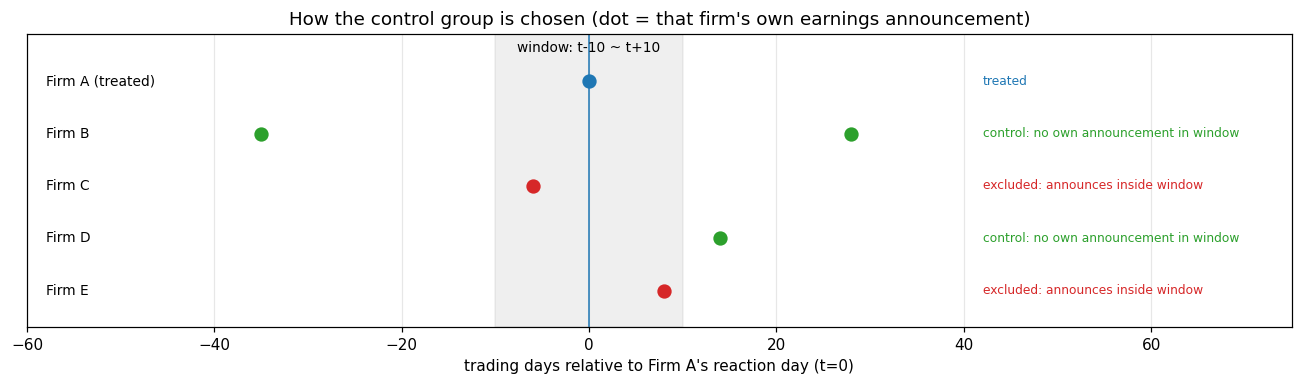

In [5]:
# 실험 설계 그림: 대조군을 고르는 규칙
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.axvspan(-WIN, WIN, color="gray", alpha=0.12)
ax.text(0, 4.55, f"window: t-{WIN} ~ t+{WIN}", ha="center", fontsize=9)
rows = [("Firm A (treated)", [0], "tab:blue"),
        ("Firm B", [-35, 28], "tab:green"),
        ("Firm C", [-6], "tab:red"),
        ("Firm D", [14], "tab:green"),
        ("Firm E", [8], "tab:red")]
for i, (name, ann, color) in enumerate(rows[::-1]):
    ax.scatter(ann, [i] * len(ann), s=70, color=color, zorder=3)
    label = "treated" if "treated" in name else ("control: no own announcement in window" if color == "tab:green" else "excluded: announces inside window")
    ax.text(-58, i, name, va="center", ha="left", fontsize=9)
    ax.text(42, i, label, va="center", fontsize=8, color=color)
ax.axvline(0, color="tab:blue", lw=1)
ax.set_xlim(-60, 75); ax.set_ylim(-0.7, 4.9); ax.set_yticks([])
ax.set_xlabel("trading days relative to Firm A's reaction day (t=0)")
ax.set_title("How the control group is chosen (dot = that firm's own earnings announcement)")
plt.tight_layout(); savefig("00_design_control_rule"); plt.show()

**위 그림 읽는 법**
- 가로축은 회사 A의 반응일(t=0) 기준 며칠 전/후인지입니다. 회색 칠한 구간이 앞뒤 10거래일입니다.
- 점은 각 회사가 **자기 실적을 발표한 날**입니다.
- 회사 B, D는 회색 구간 안에 자기 발표가 없으니 **대조군(초록)**이 됩니다.
- 회사 C, E는 회색 구간 안에 자기 발표가 있어서 **제외(빨강)**됩니다. 자기 발표 때문에 주가가 움직이면 비교 기준으로 쓸 수 없기 때문입니다.

## 5. 용어 사전

| 용어 | 쉬운 뜻 | 예시 |
|---|---|---|
| EPS | 주식 1주당 순이익 | 순이익 100억 ÷ 주식 1천만 주 = 1,000원 |
| 예상 EPS (컨센서스) | 발표 전 애널리스트들이 예상한 EPS의 평균 | 3명이 0.9, 1.0, 1.1 예상 → 1.0 |
| 서프라이즈(%) | 실제가 예상보다 몇 % 더 나왔나 | 예상 1.0, 실제 1.1 → +10% |
| 회사 기준 점수 | 이번 서프라이즈가 그 회사 평소보다 얼마나 큰가 | 위 4-3 참고 |
| 반응일 (t=0) | 주가가 발표에 처음 반응할 수 있는 날 | 장 마감 후 발표 → 다음 날 |
| 초과수익률 | 회사 주가 변화 − 같은 날 S&P500 변화 | 애플 +5%, 시장 +1% → +4% |
| 주가 흔들림 | 초과수익률의 크기 (방향 무시) | +4%든 −4%든 4 |
| 주가 방향 | 초과수익률 그대로 (올랐나 내렸나) | +4% 또는 −4% |
| 거래량 (평소 대비) | 반응일 60~21거래일 전 평균 거래량 대비. 로그로 계산하고 "몇 배"로 보고 | 로그 0 = 평소, 0.69 ≈ 2배, 1.1 ≈ 3배 |
| %p (퍼센트포인트) | % 끼리의 차이 | 7% − 1.4% = 5.6%p |
| 처치군 / 대조군 | 효과를 보고 싶은 쪽 / 비교 기준이 되는 쪽 | 발표한 회사 / 그 시기 발표 없는 회사 |
| DiD (이중차분법) | (처치군 변화) − (대조군 변화) | (108−100) − (103−100) = 5 |
| 미니 실험 (묶음) | 발표 1건 + 그때의 대조군들 | 애플 2025-08-01 묶음 |
| Stacked DiD | 미니 실험들을 세로로 쌓아서 한 번에 계산하는 방법 | |
| 평행추세 | "발표가 없었다면 처치군도 대조군과 나란히 움직였을 것"이라는 가정. 기준 구간에서 두 그룹이 나란한지로 확인 | |
| 사전 효과 (예고효과) | 발표 **전에** 이미 생긴 움직임 | 발표 전날 거래량 증가 |
| 이벤트 스터디 그래프 | 날짜별 효과를 점으로 이은 그래프 | |
| 기울기 | 점수가 1 올라갈 때 결과가 얼마나 달라지나 | 점수 1당 +2%p |
| 95% 범위 (신뢰구간) | "진짜 값은 거의 이 범위 안에 있다" | 4.7 ~ 6.4 |
| 의미 있음 | 95% 범위가 0을 포함하지 않음 = 우연이라고 보기 어려움 | 4.7 ~ 6.4 → 의미 있음 |
| 클러스터 표준오차 | 같은 회사에서 나온 여러 관측치를 한 묶음으로 보고 계산. 같은 회사가 여러 번 나와서 생기는 과신을 막음 | 애플 19번 발표 = 회사 1개 |
| 부트스트랩 | 회사를 무작위로 다시 뽑아 수백 번 다시 계산해서, 결과가 얼마나 흔들리는지로 범위를 정하는 방법 | |
| 검증 (Robustness check) | 조건을 바꿔도 결과가 버티는지 확인 | 시장 충격일 빼고 다시 |
| 가짜 발표일 검증 (Placebo) | 아무 일 없던 날을 발표일이라고 속이고 계산. 효과가 0이 나와야 정상 | 실제 45일 전 |

## 6. 데이터 수집 ① 회사 목록

**하는 일**
1. 위키피디아의 S&P500 구성종목 표에서 섹터·세부업종(GICS 분류)과 함께 회사 목록을 가져옵니다.
2. 3번 설정에 따라 섹터와 세부업종을 거릅니다. (IT라면 반도체 제외)
3. 위키피디아 접속이 안 되면, IT에 한해 미리 넣어 둔 예비 목록을 씁니다.

In [6]:
def load_universe():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=20).text
    sp = pd.read_html(StringIO(html))[0]
    sp = sp.rename(columns={"Symbol": "ticker", "Security": "name", "GICS Sector": "sector", "GICS Sub-Industry": "sub_industry"})
    sp["ticker"] = sp["ticker"].str.replace(".", "-", regex=False)     # 야후 표기법 (BRK.B -> BRK-B)
    df = sp[sp["sector"] == GICS_SECTOR].copy()
    if INCLUDE_KEYWORDS:
        df = df[df["sub_industry"].str.contains("|".join(INCLUDE_KEYWORDS), case=False)]
    if EXCLUDE_KEYWORDS:
        df = df[~df["sub_industry"].str.contains("|".join(EXCLUDE_KEYWORDS), case=False)]
    df = df[~df["ticker"].isin(EXCLUDE_TICKERS)]
    return df[["ticker", "name", "sub_industry"]].reset_index(drop=True)

FALLBACK_IT = [
    ("AAPL", "Apple", "Technology Hardware, Storage & Peripherals"), ("MSFT", "Microsoft", "Systems Software"),
    ("ORCL", "Oracle", "Application Software"), ("CRM", "Salesforce", "Application Software"),
    ("ADBE", "Adobe", "Application Software"), ("NOW", "ServiceNow", "Systems Software"),
    ("INTU", "Intuit", "Application Software"), ("PANW", "Palo Alto Networks", "Systems Software"),
    ("CRWD", "CrowdStrike", "Systems Software"), ("FTNT", "Fortinet", "Systems Software"),
    ("ADSK", "Autodesk", "Application Software"), ("WDAY", "Workday", "Application Software"),
    ("CDNS", "Cadence", "Application Software"), ("SNPS", "Synopsys", "Application Software"),
    ("PLTR", "Palantir", "Application Software"), ("DDOG", "Datadog", "Application Software"),
    ("ACN", "Accenture", "IT Consulting & Other Services"), ("IBM", "IBM", "IT Consulting & Other Services"),
    ("CTSH", "Cognizant", "IT Consulting & Other Services"), ("CSCO", "Cisco", "Communications Equipment"),
    ("ANET", "Arista Networks", "Communications Equipment"), ("MSI", "Motorola Solutions", "Communications Equipment"),
    ("LITE", "Lumentum", "Communications Equipment"), ("DELL", "Dell", "Technology Hardware, Storage & Peripherals"),
    ("HPQ", "HP", "Technology Hardware, Storage & Peripherals"), ("HPE", "HP Enterprise", "Technology Hardware, Storage & Peripherals"),
    ("STX", "Seagate", "Technology Hardware, Storage & Peripherals"), ("WDC", "Western Digital", "Technology Hardware, Storage & Peripherals"),
    ("APH", "Amphenol", "Electronic Components"), ("GLW", "Corning", "Electronic Components"),
    ("TEL", "TE Connectivity", "Electronic Manufacturing Services"), ("KEYS", "Keysight", "Electronic Equipment & Instruments"),
    ("COHR", "Coherent", "Electronic Components"), ("ZBRA", "Zebra", "Electronic Equipment & Instruments"),
]

try:
    universe = load_universe()
    print(f"위키피디아에서 불러옴: 후보 {len(universe)}개")
except Exception as e:
    if GICS_SECTOR != "Information Technology":
        raise RuntimeError("위키피디아 접속 실패. IT 외 섹터는 예비 목록이 없어서, 잠시 후 다시 실행해 주세요.") from e
    print("위키피디아 접속 실패 → IT 예비 목록 사용:", repr(e)[:100])
    universe = pd.DataFrame(FALLBACK_IT, columns=["ticker", "name", "sub_industry"])

universe["sub_industry"].value_counts().to_frame("후보 회사 수")

위키피디아에서 불러옴: 후보 54개


,후보 회사 수
sub_industry,
Application Software,14
"Technology Hardware, Storage & Peripherals",10
Systems Software,6
Communications Equipment,6
IT Consulting & Other Services,4
Electronic Equipment & Instruments,4
Internet Services & Infrastructure,3
Electronic Components,3
Electronic Manufacturing Services,3


**시가총액으로 상위 회사 고르기**

1. 현재 시가총액을 야후에서 가져옵니다.
2. 후보 회사들의 주가를 받아서, 2022년 초 시가총액을 "지금 시가총액 × (2022년 초 주가 ÷ 지금 주가)"로 근사합니다.
3. `SELECT_BY` 기준으로 상위 `N_FIRMS`개를 고릅니다. 2022년 초에 상장돼 있지 않던 회사는 "start" 기준에서 자동으로 빠집니다.

In [7]:
def market_cap_now(ticker):
    try:
        fi = yf.Ticker(ticker).fast_info
    except Exception:
        return np.nan
    for key in ("market_cap", "marketCap"):
        try:
            v = fi[key]
            if v:
                return float(v)
        except Exception:
            pass
    return np.nan

caps = []
for t in universe["ticker"]:
    caps.append(market_cap_now(t)); time.sleep(0.3)
universe["mcap_now"] = caps

raw_all = yf.download(universe["ticker"].tolist() + ["^GSPC"], start=PRICE_START, end=EVENT_END, auto_adjust=True, progress=False)
close_all = raw_all["Close"]
p_start = close_all[close_all.index >= EVENT_START].iloc[0]
p_now = close_all.ffill().iloc[-1]
universe["mcap_2022_est"] = [m * p_start.get(t, np.nan) / p_now.get(t, np.nan) if pd.notna(m) else np.nan
                             for t, m in zip(universe["ticker"], universe["mcap_now"])]

rank_col = "mcap_2022_est" if SELECT_BY == "start" else "mcap_now"
firms = (universe.dropna(subset=[rank_col]).sort_values(rank_col, ascending=False)
         .head(N_FIRMS).reset_index(drop=True))
firms["group"] = firms["sub_industry"].map(GROUP_MAP).fillna(firms["sub_industry"]) if GROUP_MAP else firms["sub_industry"]
for t, g in GROUP_OVERRIDE.items():
    firms.loc[firms["ticker"] == t, "group"] = g
firms["mcap_2022_bil"] = (firms["mcap_2022_est"] / 1e9).round(0)
firms["mcap_now_bil"] = (firms["mcap_now"] / 1e9).round(0)
tickers = firms["ticker"].tolist()
GRP = dict(zip(firms["ticker"], firms["group"]))

print(f"선택 기준: {rank_col} / 선택된 회사: {len(tickers)}개")
firms[["ticker", "name", "group", "mcap_2022_bil", "mcap_now_bil"]]

선택 기준: mcap_2022_est / 선택된 회사: 30개


,ticker,name,group,mcap_2022_bil,mcap_now_bil
0,AAPL,Apple Inc.,Hardware & Storage,2595.0,4869.0
1,MSFT,Microsoft,Software,2390.0,3930.0
2,ORCL,Oracle Corporation,Software,250.0,439.0
3,ACN,Accenture,IT Services,230.0,118.0
4,ADBE,Adobe Inc.,Software,220.0,93.0
5,CSCO,Cisco,Comm Equipment & Optical,217.0,465.0
6,CRM,Salesforce,Software,206.0,185.0
7,INTU,Intuit,Software,163.0,77.0
8,NOW,ServiceNow,Software,132.0,143.0
9,IBM,IBM,IT Services,107.0,208.0


## 7. 데이터 수집 ② 주가·거래량

선택한 회사들과 S&P500 지수(`^GSPC`)의 일별 주가·거래량입니다.
- 주가는 배당·주식 분할이 반영된 수정주가입니다 (`auto_adjust=True`).
- **초과수익률(%)** = 회사 수익률 − S&P500 수익률
- **거래량(평소 대비)** = 로그 거래량 − 반응일 60~21거래일 전 로그 거래량 평균

In [8]:
close = close_all[tickers + ["^GSPC"]]
volume = raw_all["Volume"][tickers + ["^GSPC"]]
trading_days = close.index
T, N = len(trading_days), len(tickers)
col = {t: k for k, t in enumerate(tickers)}

ret = close.pct_change()
R = ret[tickers].to_numpy()
M = ret["^GSPC"].to_numpy()
C = close[tickers].to_numpy()
LV = np.log(volume[tickers].where(volume[tickers] > 0)).to_numpy()
ABN = (R - M[:, None]) * 100        # 초과수익률 (%)
A_ABS = np.abs(ABN)                 # 주가 흔들림 (%)

print(f"거래일 {T}일 ({trading_days[0].date()} ~ {trading_days[-1].date()}), 회사 {N}개")
na = close[tickers].isna().sum()
print("주가가 비어 있는 날이 있는 회사 (중간 상장 등):", na[na > 0].to_dict() if (na > 0).any() else "없음")

거래일 1322일 (2021-07-01 ~ 2026-10-06), 회사 30개
주가가 비어 있는 날이 있는 회사 (중간 상장 등): {'NOW': 1, 'PANW': 1, 'WDAY': 1, 'DDOG': 1, 'CRWD': 1, 'ANET': 1, 'PLTR': 1, 'KEYS': 1, 'DELL': 1}


## 8. 데이터 수집 ③ 실적발표 기록

`yf.Ticker(회사).get_earnings_dates(limit=40)`로 회사마다 **최근 약 10년치** 실적발표 기록을 가져옵니다. 한 줄 = 발표 1번이고, 아래 정보가 들어 있습니다.

| 열 | 뜻 |
|---|---|
| earnings_datetime | 발표 날짜와 시각 (뉴욕 시간) |
| eps_estimate | 예상 EPS (애널리스트 평균) |
| eps_actual | 실제 EPS |

2022년 이전 기록도 받는 이유는 두 가지입니다.
1. 회사의 "평소 서프라이즈"를 지난 8분기로 계산하려면, 2022년 초 발표에도 2020~2021년 기록이 필요합니다.
2. 대조군을 고를 때, 2022년 초 실험의 구간(2021년 12월 포함)에 발표한 회사를 정확히 빼야 합니다.

In [9]:
def fetch_earnings(ticker, limit=40):
    df = yf.Ticker(ticker).get_earnings_dates(limit=limit)
    if df is None or len(df) == 0:
        return pd.DataFrame()
    df = df.reset_index()
    rename = {df.columns[0]: "earnings_datetime"}
    for c in df.columns[1:]:
        lc = str(c).lower()
        if "reported" in lc:
            rename[c] = "eps_actual"
        elif "estimate" in lc:
            rename[c] = "eps_estimate"
    df = df.rename(columns=rename)
    df["ticker"] = ticker
    return df[[c for c in ["ticker", "earnings_datetime", "eps_estimate", "eps_actual"] if c in df.columns]]

frames, failed = [], []
for t in tickers:
    try:
        d = fetch_earnings(t)
        (frames.append(d) if len(d) else failed.append(t))
    except Exception as e:
        failed.append(t); print(t, "실패:", repr(e)[:100])
    time.sleep(1.0)
earn = pd.concat(frames, ignore_index=True)
print(f"가져온 발표 기록: {len(earn)}줄 / 실패한 회사: {failed}")

가져온 발표 기록: 1416줄 / 실패한 회사: []


## 9. 데이터 정리

### 9-1. 발표 시각과 반응일 정하기

| 발표 시각 (뉴욕) | 분류 | 반응일 |
|---|---|---|
| 9:30 이전 | 장 시작 전 (BMO) | 발표 당일 |
| 9:30 ~ 16:00 | 장중 | 발표 당일 |
| 16:00 이후 | 장 마감 후 (AMC) | 다음 거래일 |
| 00:00으로 기록됨 | 시각 모름 | 발표 당일 (따로 표시) |

### 9-2. 서프라이즈(%) 계산

> 서프라이즈(%) = (실제 EPS − 예상 EPS) ÷ |예상 EPS| × 100

- 이전 파일럿에서는 "주가"로 나눴는데, 이번엔 "예상 EPS"로 나눕니다. 회사 기준 점수에서는 그 회사 안에서만 비교하니까 주가로 나눌 필요가 없고, 이렇게 하면 **주식 분할 전후로 숫자가 어긋나는 문제**도 생기지 않습니다. (분할 전 EPS와 분할 후 주가가 섞이면 값이 몇 배씩 틀어질 수 있습니다)
- 예상 EPS가 0.01달러처럼 0에 가까우면 %가 폭발하므로(예: +700%), −100% ~ +100% 사이로 자릅니다.

In [10]:
def to_ny(ts):
    ts = pd.Timestamp(ts)
    return ts.tz_localize("America/New_York") if ts.tzinfo is None else ts.tz_convert("America/New_York")

def classify_timing(ts):
    h = ts.hour + ts.minute / 60
    if h == 0:
        return "unknown"
    if h < 9.5:
        return "BMO"
    if h >= 16:
        return "AMC"
    return "during"

def reaction_pos(day, timing):
    if day < trading_days[0] or day > trading_days[-1]:
        return np.nan                                   # 주가 데이터 범위 밖
    pos = trading_days.searchsorted(day)                # 당일 또는 그다음 첫 거래일
    if timing == "AMC" and pos < T and trading_days[pos] == day:
        pos += 1
    return pos if pos < T else np.nan

e = earn.copy()
e["eps_estimate"] = pd.to_numeric(e["eps_estimate"], errors="coerce")
e["eps_actual"] = pd.to_numeric(e["eps_actual"], errors="coerce")
e["earnings_datetime"] = e["earnings_datetime"].apply(to_ny)
e["earnings_date"] = e["earnings_datetime"].apply(lambda x: pd.Timestamp(x.date()))
e = e[e["eps_actual"].notna()].copy()                                     # 이미 발표된 것만
e = e.drop_duplicates(subset=["ticker", "earnings_date"]).sort_values(["ticker", "earnings_datetime"]).reset_index(drop=True)
e["timing"] = e["earnings_datetime"].apply(classify_timing)
e["t0_pos"] = [reaction_pos(d, tm) for d, tm in zip(e["earnings_date"], e["timing"])]

valid_est = e["eps_estimate"].notna() & (e["eps_estimate"] != 0)
e["surprise_pct"] = np.where(valid_est, (e["eps_actual"] - e["eps_estimate"]) / e["eps_estimate"].abs() * 100, np.nan)
e["surprise_pct"] = e["surprise_pct"].clip(-SURPRISE_CLIP, SURPRISE_CLIP)

# 대조군 판정용: 회사별 "모든" 발표 반응일 위치 (2022년 이전 포함, 주가 범위 안의 것만)
ANN = {t: np.sort(e.loc[(e["ticker"] == t) & e["t0_pos"].notna(), "t0_pos"].astype(int).unique()) for t in tickers}
print(f"정리된 발표 기록: {len(e)}건 (2022년 이전 포함)")

정리된 발표 기록: 1383건 (2022년 이전 포함)


### 9-3. 회사 기준 서프라이즈 점수 계산

발표마다 아래 순서로 계산합니다.
1. 그 회사의 발표 기록을 날짜순으로 놓습니다.
2. 이번 발표 **바로 전까지의** 최근 8분기 서프라이즈를 모읍니다. (최소 4분기가 있어야 계산. 미래 정보를 쓰지 않기 위해 이번 발표와 그 이후는 절대 쓰지 않습니다)
3. 그 8분기의 평균 = 평소 서프라이즈, 표준편차 = 평소 오르내리는 폭
4. 점수 = (이번 − 평균) ÷ 표준편차
   - 표준편차가 1%p보다 작으면 1%p로 바꿔서 나눕니다. 매번 거의 똑같이 넘기는 회사는 표준편차가 0에 가까워서, 조금만 달라도 점수가 폭발하기 때문입니다.
   - 점수는 −5 ~ +5 사이로 자릅니다.

**비교용 점수 (검증에서 씀)**: "시장 전체 기준 점수" = 이번 서프라이즈(%)를 모든 발표의 평균·표준편차로 표준화한 것. 회사의 평소를 고려하지 않은 점수입니다.

In [11]:
def add_firm_scores(df):
    out = []
    for t, g in df.groupby("ticker"):
        g = g.sort_values("earnings_datetime").copy()
        s = g["surprise_pct"].to_numpy()
        mean_, sd_, n_ = [], [], []
        for i in range(len(g)):
            past = s[:i][~np.isnan(s[:i])][-HIST_QUARTERS:]
            if len(past) >= HIST_MIN:
                mean_.append(past.mean()); sd_.append(past.std(ddof=1)); n_.append(len(past))
            else:
                mean_.append(np.nan); sd_.append(np.nan); n_.append(len(past))
        g["hist_mean"], g["hist_sd"], g["n_hist"] = mean_, sd_, n_
        out.append(g)
    df = pd.concat(out)
    denom = np.maximum(df["hist_sd"], SCORE_FLOOR)
    df["score"] = ((df["surprise_pct"] - df["hist_mean"]) / denom).clip(-SCORE_CLIP, SCORE_CLIP)
    return df

e = add_firm_scores(e)

# 분석 대상 발표: 기간 안 + 반응일과 앞뒤 구간의 주가가 다 있는 것
def full_prices(c, p, post=WIN):
    return bool(np.isfinite(C[p - BASE_START: p + post + 1, c]).all())

ev = e[(e["earnings_date"] >= pd.Timestamp(EVENT_START)) & (e["earnings_date"] <= pd.Timestamp(EVENT_END)) & e["t0_pos"].notna()].copy()
ev["t0_pos"] = ev["t0_pos"].astype(int)
ev = ev[(ev["t0_pos"] - BASE_START >= 0) & (ev["t0_pos"] + WIN <= T - 1)].copy()
ev["ok_prices"] = [full_prices(col[t], p) for t, p in zip(ev["ticker"], ev["t0_pos"])]
ev = ev[ev["ok_prices"]].copy()
ev["t0_date"] = trading_days[ev["t0_pos"].to_numpy()]
ev["event_id"] = ev["ticker"] + "_" + ev["t0_date"].dt.strftime("%Y-%m-%d")
ev["quarter"] = ev["t0_date"].dt.to_period("Q").astype(str)
ev["group"] = ev["ticker"].map(GRP)
mu_all, sd_all = ev["surprise_pct"].mean(), ev["surprise_pct"].std()
ev["score_market"] = ((ev["surprise_pct"] - mu_all) / sd_all).clip(-SCORE_CLIP, SCORE_CLIP)
ev = ev.sort_values(["t0_date", "ticker"]).reset_index(drop=True)

print(f"분석 대상 발표: {len(ev)}건")
print(f"회사 기준 점수가 계산된 발표: {ev['score'].notna().sum()}건 (지난 기록이 4분기 미만이면 계산 안 됨)")

분석 대상 발표: 569건
회사 기준 점수가 계산된 발표: 569건 (지난 기록이 4분기 미만이면 계산 안 됨)


**점수 계산 예시 — 실제 데이터로 한 회사 따라가 보기**

아래 표와 그래프는 첫 번째 회사의 최근 발표들입니다.
- 표: 각 발표의 서프라이즈(%), 그 발표 직전 8분기의 평균과 표준편차, 그리고 점수
- 그래프: 막대 = 각 발표의 서프라이즈(%), 회색 띠 = 직전 8분기 기준 "평소 범위"(평균 ± 표준편차), 막대 위 숫자 = 점수

**읽는 법**
- 막대가 회색 점선(평소 서프라이즈)보다 높으면 "평소보다 크게 넘김" → 점수 플러스 → **파란 막대**
- 막대가 회색 점선보다 낮으면 "평소보다 덜 넘김" → 점수 마이너스 → **빨간 막대**
- 막대가 회색 띠 밖으로 많이 벗어날수록 점수의 크기(절댓값)가 커집니다.
- 예상치를 넘긴 발표(막대가 0보다 위)도 빨간 막대일 수 있습니다. "예상은 넘겼지만 그 회사 평소보다는 덜 넘겼다"는 뜻입니다.

,earnings_date,eps_estimate,eps_actual,surprise_pct,hist_mean,hist_sd,score
41,2024-10-31,0.95,0.97,2.11,3.10,3.26,-0.31
42,2025-01-30,2.35,2.40,2.13,3.17,3.23,-0.32
43,2025-05-01,1.62,1.65,1.85,3.88,1.86,-1.09
44,2025-07-31,1.43,1.57,9.79,3.33,1.70,3.81
45,2025-10-30,1.77,1.85,4.52,3.82,2.76,0.25
46,2026-01-29,2.67,2.84,6.37,3.75,2.74,0.96
47,2026-04-30,1.94,2.01,3.61,4.07,2.89,-0.16
48,2026-07-30,1.89,2.02,6.88,4.36,2.69,0.94


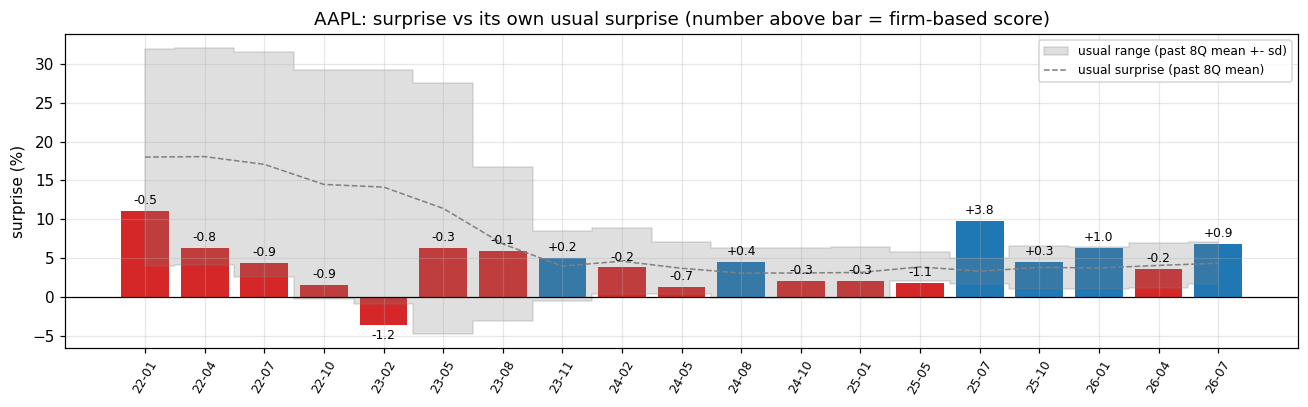

In [12]:
ex_t = "AAPL" if "AAPL" in tickers else tickers[0]
exd = e[(e["ticker"] == ex_t) & (e["earnings_date"] >= pd.Timestamp(EVENT_START))].copy()
display(exd[["earnings_date", "eps_estimate", "eps_actual", "surprise_pct", "hist_mean", "hist_sd", "score"]].round(2).tail(8))

fig, ax = plt.subplots(figsize=(12, 3.8))
x = np.arange(len(exd))
ax.bar(x, exd["surprise_pct"], color=["tab:blue" if s >= 0 else "tab:red" for s in exd["score"].fillna(0)])
ax.fill_between(x, exd["hist_mean"] - exd["hist_sd"], exd["hist_mean"] + exd["hist_sd"], color="gray", alpha=0.25, step="mid", label="usual range (past 8Q mean +- sd)")
ax.plot(x, exd["hist_mean"], color="gray", lw=1, ls="--", label="usual surprise (past 8Q mean)")
for xi, (s, sc) in enumerate(zip(exd["surprise_pct"], exd["score"])):
    if pd.notna(sc):
        lab = "0.0" if abs(sc) < 0.05 else f"{sc:+.1f}"
        ax.text(xi, s + (0.5 if s >= 0 else -0.5), lab, ha="center", va="bottom" if s >= 0 else "top", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(exd["earnings_date"].dt.strftime("%y-%m"), rotation=60, fontsize=8)
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("surprise (%)"); ax.legend(fontsize=8)
ax.set_title(f"{ex_t}: surprise vs its own usual surprise (number above bar = firm-based score)")
plt.tight_layout(); savefig("01_score_example"); plt.show()

## 10. 데이터 점검

본 분석 전에 데이터가 충분하고 정확한지 확인합니다.

### 10-1. 회사별 발표 건수

2022년 1월부터 지금까지면 회사당 **약 19분기**가 정상입니다.
- `n_events`: 분석에 쓰는 발표 수
- `n_scored`: 그중 회사 기준 점수가 계산된 발표 수 (지난 기록이 부족하면 빠짐)
- `status`: 기대치의 75% 미만이면 "부족"

In [13]:
n_expected = round((pd.Timestamp(EVENT_END) - pd.Timestamp(EVENT_START)).days / 91.25)
cov = ev.groupby("ticker").agg(n_events=("event_id", "size"), n_scored=("score", lambda s: s.notna().sum()),
                               first=("t0_date", "min"), last=("t0_date", "max")).reset_index()
cov = firms[["ticker", "name", "group"]].merge(cov, on="ticker", how="left")
cov[["n_events", "n_scored"]] = cov[["n_events", "n_scored"]].fillna(0).astype(int)
cov["status"] = np.where(cov["n_events"] >= 0.75 * n_expected, "OK", "부족")
print(f"기대 분기 수: 약 {n_expected} / OK {int((cov.status == 'OK').sum())}개, 부족 {int((cov.status == '부족').sum())}개")
cov.to_csv(OUT_DIR / "check_coverage.csv", index=False)
cov.sort_values("n_events")

기대 분기 수: 약 19 / OK 30개, 부족 0개


,ticker,name,group,n_events,n_scored,first,last,status
3,ACN,Accenture,IT Services,18,18,2022-03-17,2026-06-18,OK
0,AAPL,Apple Inc.,Hardware & Storage,19,19,2022-01-28,2026-07-31,OK
1,MSFT,Microsoft,Software,19,19,2022-01-26,2026-07-30,OK
2,ORCL,Oracle Corporation,Software,19,19,2022-03-11,2026-09-11,OK
4,ADBE,Adobe Inc.,Software,19,19,2022-03-23,2026-09-11,OK
5,CSCO,Cisco,Comm Equipment & Optical,19,19,2022-02-17,2026-08-13,OK
6,CRM,Salesforce,Software,19,19,2022-03-02,2026-08-27,OK
7,INTU,Intuit,Software,19,19,2022-02-25,2026-08-26,OK
8,NOW,ServiceNow,Software,19,19,2022-01-27,2026-07-23,OK
9,IBM,IBM,IT Services,19,19,2022-01-25,2026-07-23,OK


### 10-2. 발표 시각

- 막대 그래프: 발표 시각 분류별 건수입니다. 미국 IT 대기업은 대부분 장 마감 후(AMC)에 발표합니다.
- 표: 회사별로 장 전/장 후 발표가 **섞여 있는** 회사를 찾습니다. 대부분 회사는 한 가지 습관을 유지하는데, 섞여 있으면 회사가 시간을 바꿨거나 야후 기록이 틀렸을 수 있습니다. 소수 쪽 비율이 25% 이상인 회사를 "시각 섞임"으로 표시하고, 검증에서 빼고 다시 돌려봅니다.

timing
AMC       425
BMO       142
during      2

발표 시각이 섞인 회사: ['PLTR']


timing,AMC,BMO,during
ticker,,,
PLTR,14,5,0


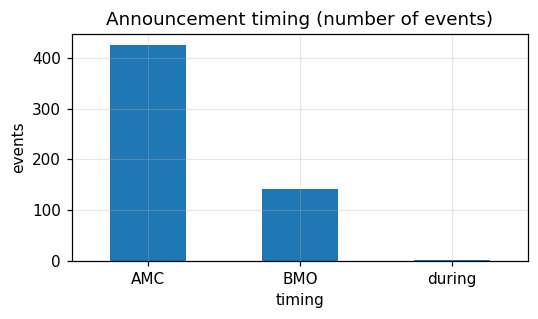

In [14]:
print(ev["timing"].value_counts().to_string())
ct = pd.crosstab(ev["ticker"], ev["timing"])
minority = ct.div(ct.sum(axis=1), axis=0)
minority = minority.apply(lambda r: r.sort_values(ascending=False).iloc[1] if len(r) > 1 else 0, axis=1)
MIXED_TIMING = minority[minority >= 0.25].index.tolist()
print("\n발표 시각이 섞인 회사:", MIXED_TIMING if MIXED_TIMING else "없음")
display(ct.loc[MIXED_TIMING] if MIXED_TIMING else ct.head(0))

ev["timing"].value_counts().plot(kind="bar", figsize=(5, 3), title="Announcement timing (number of events)")
plt.xticks(rotation=0); plt.ylabel("events"); plt.tight_layout(); savefig("02_timing"); plt.show()

### 10-3. 반응일이 맞게 잡혔나 (날짜 오류 의심 찾기)

**아이디어**: 진짜 반응일이면 그날 주가가 제일 크게 움직여야 합니다. 그래서 반응일 전날(t−1), 당일(t=0), 다음날(t+1) 중 언제 주가 흔들림이 가장 컸는지 봅니다.

| 예시 | t−1 | t=0 | t+1 | 판정 |
|---|---|---|---|---|
| 정상 | 1.2% | **9.5%** | 2.0% | t=0이 최대 → 정렬 맞음 |
| 의심 | **8.7%** | 1.5% | 1.1% | 옆날이 훨씬 큼 → 날짜가 하루 틀렸을 수 있음 |

**의심 기준**: 옆날 흔들림이 t=0의 2배 이상이면서 3% 이상

**자동으로 고치지 않는 이유**: "제일 크게 움직인 날"로 반응일을 옮겨 버리면, 효과가 제일 크게 보이는 날을 골라 쓰는 셈이라 결과가 부풀려집니다. 대신 **의심 발표를 빼고 다시 돌려보는 검증**을 합니다.

**막대 그래프 읽는 법**: 회사별로 "t=0에 가장 크게 움직인 발표의 비율"입니다. 대부분 70% 이상이면 정렬이 잘 된 것입니다. 원래 반응이 작은 회사는 우연히 옆날이 클 수 있어서 비율이 낮게 나올 수 있습니다. 빨간 막대는 발표 시각이 섞인 회사입니다.

t=0에 가장 크게 움직인 발표: 79% / 날짜 의심 발표: 38건


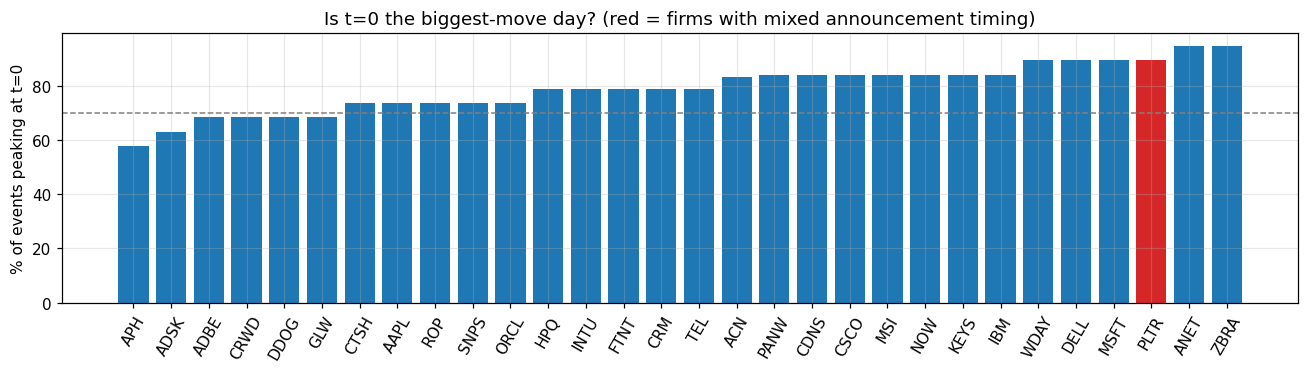

,event_id,timing,peak_day
7,ROP_2022-02-02,BMO,1
19,PANW_2022-02-23,AMC,1
23,HPQ_2022-03-01,AMC,1
43,FTNT_2022-05-05,AMC,1
72,DDOG_2022-08-04,BMO,-1
102,DDOG_2022-11-03,BMO,1
130,MSI_2023-02-09,during,1
175,CRWD_2023-06-01,AMC,1
176,DELL_2023-06-01,during,-1
177,ORCL_2023-06-13,AMC,-1


In [15]:
peak, side_max, t0_val = [], [], []
for t, p in zip(ev["ticker"], ev["t0_pos"]):
    v = A_ABS[p - 1: p + 2, col[t]]
    peak.append(int(np.nanargmax(v)) - 1); side_max.append(max(v[0], v[2])); t0_val.append(v[1])
ev["peak_day"] = peak
ev["misaligned"] = (ev["peak_day"] != 0) & (np.array(side_max) >= 2 * np.array(t0_val)) & (np.array(side_max) >= 3)
share = ev.groupby("ticker")["peak_day"].apply(lambda s: (s == 0).mean()).sort_values()
print(f"t=0에 가장 크게 움직인 발표: {(ev['peak_day'] == 0).mean():.0%} / 날짜 의심 발표: {int(ev['misaligned'].sum())}건")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(share.index, share.values * 100, color=["tab:red" if t in MIXED_TIMING else "tab:blue" for t in share.index])
ax.axhline(70, color="gray", ls="--", lw=1)
ax.set_ylabel("% of events peaking at t=0"); ax.set_title("Is t=0 the biggest-move day? (red = firms with mixed announcement timing)")
plt.xticks(rotation=60); plt.tight_layout(); savefig("03_timing_check"); plt.show()
ev.loc[ev["misaligned"], ["event_id", "timing", "peak_day"]].head(15)

### 10-4. 서프라이즈와 회사 기준 점수 분포

- **왼쪽**: 서프라이즈(%) 분포. 빨간 선이 0입니다. 미국 IT 대기업은 대부분 예상을 넘겨서 **오른쪽(플러스)에 몰려 있을 것**입니다.
- **오른쪽**: 회사 기준 점수 분포. 각 회사의 평소를 빼고 나눴기 때문에 **0을 중심으로 좌우로 퍼져 있어야** 정상입니다.

즉, 왼쪽은 "예상치 대비"라서 거의 다 플러스지만, 오른쪽은 "그 회사 평소 대비"라서 플러스와 마이너스가 고르게 나옵니다. 이게 회사 기준 점수를 쓰는 이유입니다.

예상치를 넘긴 발표 비율: 90%
회사 기준 점수: 평균 -0.13, 플러스 39%, 마이너스 61%


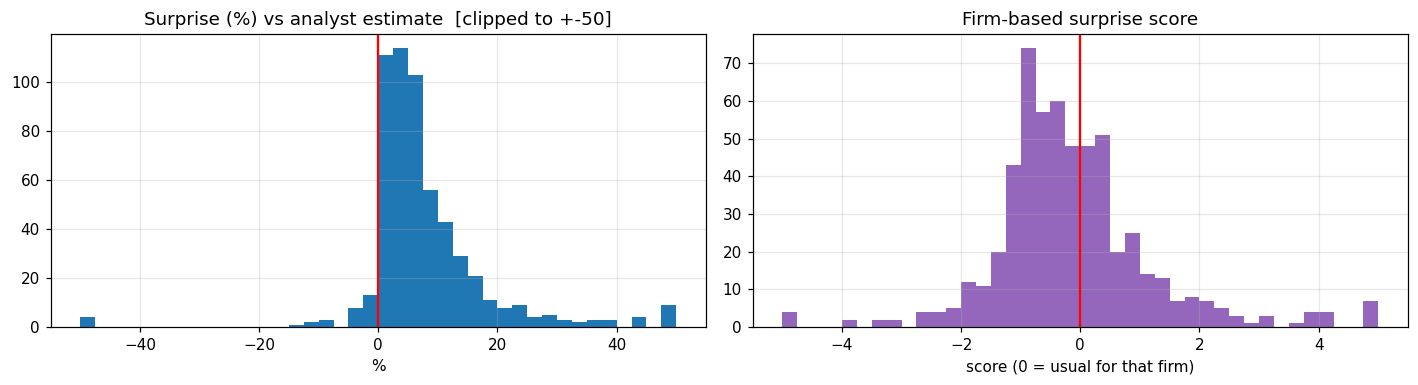

In [16]:
s_ok = ev.dropna(subset=["surprise_pct"])
print(f"예상치를 넘긴 발표 비율: {(s_ok['surprise_pct'] > 0).mean():.0%}")
print(f"회사 기준 점수: 평균 {ev['score'].mean():+.2f}, 플러스 {(ev['score'] > 0).mean():.0%}, 마이너스 {(ev['score'] < 0).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
s_ok["surprise_pct"].clip(-50, 50).hist(bins=40, ax=axes[0]); axes[0].axvline(0, color="red")
axes[0].set_title("Surprise (%) vs analyst estimate  [clipped to +-50]"); axes[0].set_xlabel("%")
ev["score"].dropna().hist(bins=40, ax=axes[1], color="tab:purple"); axes[1].axvline(0, color="red")
axes[1].set_title("Firm-based surprise score"); axes[1].set_xlabel("score (0 = usual for that firm)")
plt.tight_layout(); savefig("04_surprise_distribution"); plt.show()

### 10-5. 시장 충격일

S&P500이 하루에 ±3% 이상 움직인 날을 "시장 충격일"로 표시합니다. 분석 구간(반응일 ±10거래일) 안에 이런 날이 낀 발표는 검증에서 빼고 다시 돌려봅니다.

참고로 시장 전체 움직임은 이미 두 겹으로 걸러집니다.
1. 초과수익률이 매일 S&P500 움직임을 빼고 계산되고
2. 처치군과 대조군이 같은 날짜를 겪으므로 비교할 때 다시 빠집니다.

이 검증은 "그래도 혹시" 확인하는 세 번째 장치입니다.

In [17]:
big_pos = np.where(np.abs(np.nan_to_num(M)) >= SHOCK)[0]
ev["has_market_shock"] = [bool(((big_pos >= p - WIN) & (big_pos <= p + WIN)).any()) for p in ev["t0_pos"]]
print(f"시장 충격일: {len(big_pos)}일 / 구간 안에 충격일이 낀 발표: {ev['has_market_shock'].mean():.0%}")
print((pd.Series(M[big_pos] * 100, index=trading_days[big_pos]).round(2)).to_string())

시장 충격일: 17일 / 구간 안에 충격일이 낀 발표: 16%
Date
2022-04-29   -3.63
2022-05-05   -3.56
2022-05-09   -3.20
2022-05-18   -4.04
2022-06-13   -3.88
2022-06-16   -3.25
2022-06-24    3.06
2022-08-26   -3.37
2022-09-13   -4.32
2022-10-04    3.06
2022-11-10    5.54
2022-11-30    3.09
2025-04-03   -4.84
2025-04-04   -5.97
2025-04-09    9.52
2025-04-10   -3.46
2025-05-12    3.26


---
# 11. 발표 효과 분석

> **질문**: 실적을 발표하면 주가와 거래량이 얼마나 달라지나요?
> **비교**: 발표한 회사(처치군) vs 그 반응일 앞뒤 10거래일 동안 자기 발표가 없는 같은 섹터 회사(대조군)

## 11-1. 미니 실험 만들기

발표 1건마다 아래를 반복합니다.
1. 그 발표의 반응일(t=0) 기준 앞뒤 10거래일 구간을 잡습니다.
2. 같은 섹터의 나머지 회사 중에서, **그 구간에 자기 발표가 없는** 회사를 대조군으로 고릅니다.
3. 대조군은 구간 전체(평소 거래량 기준 구간 포함)의 주가 데이터가 있어야 합니다.
4. 처치군 1개 + 대조군 여러 개의 t−10 ~ t+10 데이터를 한 묶음으로 저장합니다.

이 묶음들을 전부 세로로 쌓은 것이 **Stacked 패널**입니다. 이렇게 하면 "이미 발표한 회사를 대조군으로 잘못 쓰는" 문제가 생기지 않습니다.

In [18]:
def announces_in(ticker, lo, hi):
    a = ANN[ticker]
    return bool(((a >= lo) & (a <= hi)).any())

def series(c, p, rel):
    q = p + rel
    base = np.nanmean(LV[p - BASE_START: p - BASE_END + 1, c])
    return ABN[q, c], A_ABS[q, c], LV[q, c] - base

def _new():
    return {k: [] for k in ["block", "member", "ticker", "treat", "rel_day", "abn_ret", "abs_ret", "vol"]}

def _add(store, block, member, ticker, treat, rel, s):
    n = len(rel)
    for k, v in [("block", block), ("member", member), ("ticker", ticker), ("treat", treat)]:
        store[k].append(np.repeat(v, n))
    store["rel_day"].append(rel)
    store["abn_ret"].append(s[0]); store["abs_ret"].append(s[1]); store["vol"].append(s[2])

def _done(store):
    if not store["block"]:
        return pd.DataFrame(columns=list(store))
    return pd.DataFrame({k: np.concatenate(v) for k, v in store.items()})

def pick_controls(event_ticker, p, pre, post, diff_group=False, exclude=()):
    return [j for j in tickers
            if j != event_ticker and j not in exclude
            and not (diff_group and GRP[j] == GRP[event_ticker])
            and not announces_in(j, p - pre, p + post)
            and full_prices(col[j], p, post)]

def build_announcement_stack(events, pre=WIN, post=WIN, shift=0, diff_group=False, exclude=()):
    rel = np.arange(-pre, post + 1)
    store, n_ctrl = _new(), {}
    for x in events.itertuples():
        if x.ticker in exclude:
            continue
        p = int(x.t0_pos) + shift
        if p - BASE_START < 0 or p + post > T - 1 or not full_prices(col[x.ticker], p, post):
            continue
        if shift != 0 and announces_in(x.ticker, p - pre, p + post):
            continue
        ctrls = pick_controls(x.ticker, p, pre, post, diff_group, exclude)
        if not ctrls:
            continue
        blk = x.event_id if shift == 0 else f"{x.event_id}_fake"
        _add(store, blk, x.ticker, x.ticker, 1, rel, series(col[x.ticker], p, rel))
        for j in ctrls:
            _add(store, blk, j, j, 0, rel, series(col[j], p, rel))
        n_ctrl[blk] = len(ctrls)
    return _done(store), pd.Series(n_ctrl, dtype=float)

stack, nctrl = build_announcement_stack(ev)
print(f"미니 실험 수: {len(nctrl)}개 (전체 발표 {len(ev)}건 중 대조군이 1개 이상인 것)")
print(f"실험당 대조군 수: 평균 {nctrl.mean():.1f}개, 최소 {nctrl.min():.0f}개, 최대 {nctrl.max():.0f}개")
print(f"패널 크기: {stack.shape[0]:,}줄")

미니 실험 수: 569개 (전체 발표 569건 중 대조군이 1개 이상인 것)
실험당 대조군 수: 평균 15.8개, 최소 7개, 최대 28개
패널 크기: 200,172줄


**미니 실험 하나를 그림으로**

- **왼쪽 그림 (대조군 고르는 과정)**: 가로 = 예시 발표의 반응일 기준 며칠 전/후, 세로 = 회사. 점 = 그 회사가 자기 실적을 발표한 날. 회색 구간(±10거래일) 안에 점이 있으면 탈락(빨강), 없으면 대조군(초록), 파랑은 처치군입니다.
- **오른쪽 그림 (그 실험 안의 실제 데이터)**: 파란 선 = 처치군의 주가 흔들림, 회색 선들 = 대조군 각각, 주황 선 = 대조군 평균. 반응일(빨간 세로선)에 파란 선만 튀어 오르면, 그게 이 발표 하나의 효과입니다.

발표 하나만 보면 들쭉날쭉하지만, 수백 개를 평균내면 효과가 또렷해집니다. 그게 다음 단계입니다.

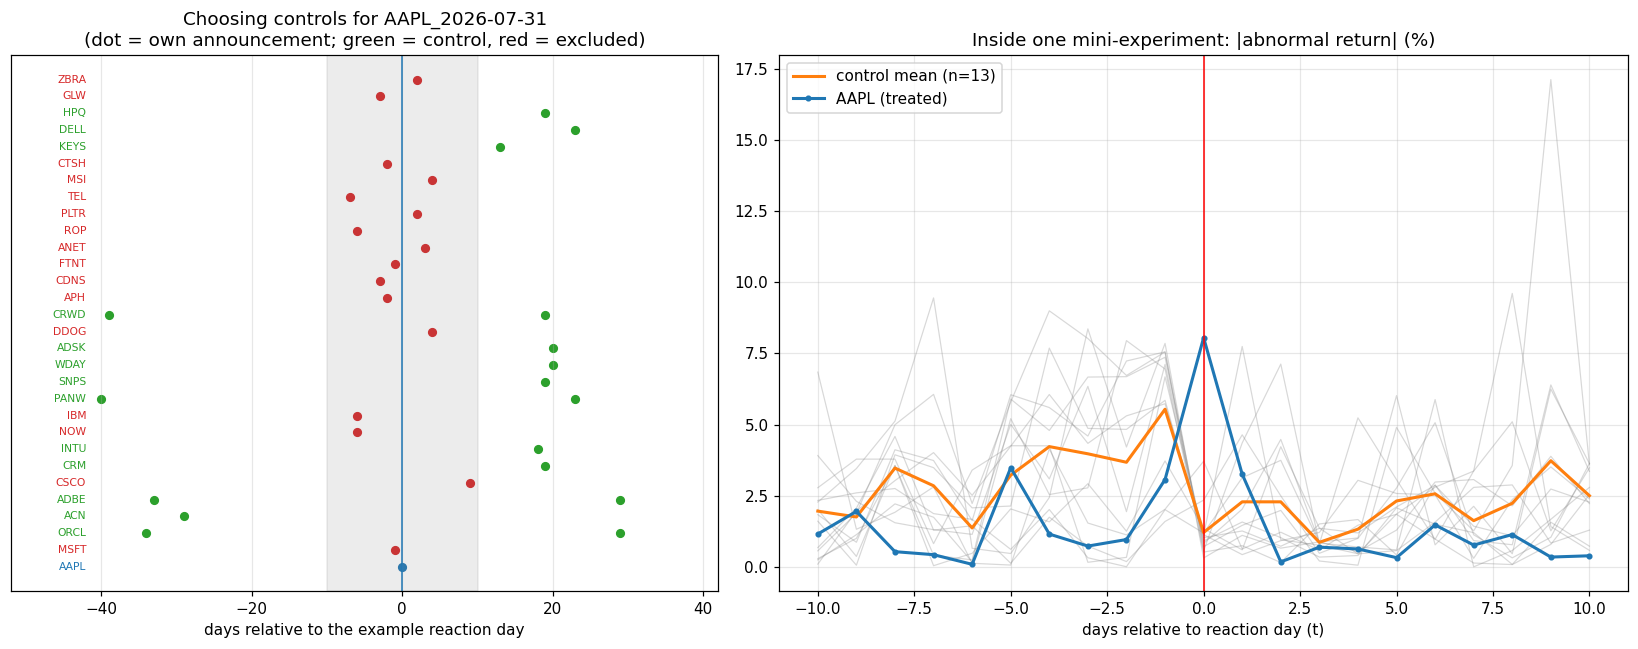

In [19]:
cand = ev[(ev["ticker"] == ex_t) & ev["event_id"].isin(nctrl.index)]
ex = cand.iloc[-1] if len(cand) else ev[ev["event_id"].isin(nctrl.index)].iloc[-1]
ex_t = ex["ticker"]
p0 = int(ex["t0_pos"])
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.2]})
ax = axes[0]
for i, j in enumerate(tickers):
    a = ANN[j]; a = a[(a >= p0 - 40) & (a <= p0 + 40)] - p0
    ok = (j != ex_t) and not announces_in(j, p0 - WIN, p0 + WIN) and full_prices(col[j], p0)
    color = "tab:blue" if j == ex_t else ("tab:green" if ok else "tab:red")
    ax.scatter(a, [i] * len(a), color=color, s=25)
    ax.text(-42, i, j, va="center", ha="right", fontsize=7, color=color)
ax.axvspan(-WIN, WIN, color="gray", alpha=0.15); ax.axvline(0, color="tab:blue", lw=1)
ax.set_yticks([]); ax.set_xlim(-52, 42); ax.set_xlabel("days relative to the example reaction day")
ax.set_title(f"Choosing controls for {ex['event_id']}\n(dot = own announcement; green = control, red = excluded)")
ax = axes[1]
blk = stack[stack["block"] == ex["event_id"]]
for j, d in blk[blk["treat"] == 0].groupby("ticker"):
    ax.plot(d["rel_day"], d["abs_ret"], color="gray", alpha=0.3, lw=0.8)
cm = blk[blk["treat"] == 0].groupby("rel_day")["abs_ret"].mean()
tr = blk[blk["treat"] == 1].set_index("rel_day")["abs_ret"]
ax.plot(cm.index, cm.values, color="tab:orange", lw=2, label=f"control mean (n={int(nctrl[ex['event_id']])})")
ax.plot(tr.index, tr.values, "o-", color="tab:blue", lw=2, ms=3, label=f"{ex_t} (treated)")
ax.axvline(0, color="red", lw=1); ax.legend(); ax.set_xlabel("days relative to reaction day (t)")
ax.set_title("Inside one mini-experiment: |abnormal return| (%)")
plt.tight_layout(); savefig("05_example_experiment"); plt.show()

## 11-2. 계산 방법 세 가지

같은 질문을 세 가지 방법으로 계산해서 비교합니다.

**① Stacked DiD 회귀 (메인)**
- 위에서 쌓은 데이터로 회귀분석을 합니다.
- 회사×실험 고정효과: 회사마다 원래 흔들림 크기가 다른 것(높이 차이)을 지웁니다.
- 실험×날짜 고정효과: 그 실험 그날의 시장 분위기를 지웁니다.
- 남는 계수 = "처치군이 기준 구간 대비 그날 대조군보다 얼마나 더 움직였나" = 효과
- 표준오차는 회사 단위로 묶어서(클러스터) 계산합니다.

**② Callaway–Sant'Anna 방식 (확인용, 직접 구현)**
1. 실험마다 날짜별로 (처치군 값 − 대조군 평균)을 계산합니다.
2. 거기서 기준 구간의 평균 차이를 뺍니다 → 실험별 미니 DiD
3. 모든 실험을 똑같은 비중으로 평균냅니다.
4. 신뢰구간은 회사 단위 부트스트랩(회사를 무작위로 다시 뽑아 300번 반복)으로 구합니다.
- 학계 표준 패키지(R의 `did`)는 "한 번 처치받으면 계속 처치 상태"를 가정하는데, 실적발표는 분기마다 반복되어서 그대로 쓸 수 없습니다. 그래서 같은 논리를 직접 구현했습니다.

**③ 단순 회귀 TWFE (비교용)**
- 묶음을 만들지 않고 전체 기간 패널에 "반응일 표시"를 넣어 한 번에 회귀합니다.
- 발표 직전 구간이 "평소"에 섞이고, 다른 회사의 발표 직후 날들도 비교 기준에 섞입니다.
- ①②와 숫자가 다르면 "묶음을 만들어야 하는 이유"가 됩니다. 비슷하면 "이 데이터에서는 그 문제가 크지 않았다"는 뜻입니다.

In [20]:
WIN_ANN = {
    "abs_ret": dict(ref=(-WIN, -4), ant=(-3, -1), name="Stock-price swing |abnormal return| (%p)"),
    "vol":     dict(ref=(-WIN, -6), ant=(-5, -1), name="Trading volume (log, vs usual)"),
    "abn_ret": dict(ref=(-WIN, -4), ant=(-3, -1), name="Stock-price direction: abnormal return (%p)"),
}
T0_WIN = (0, 0)

def _prep(stack):
    d = stack.copy()
    d["unit"] = d["block"].astype(str) + "|" + d["member"].astype(str)
    d["bt"] = d["block"].astype(str) + "|" + d["rel_day"].astype(str)
    return d

def _tidy(fit, names):
    tb = fit.tidy(); tb.index = [str(i) for i in tb.index]
    return pd.DataFrame({"est": tb.loc[names, "Estimate"].to_numpy(), "se": tb.loc[names, "Std. Error"].to_numpy(),
                         "lo": tb.loc[names, "2.5%"].to_numpy(), "hi": tb.loc[names, "97.5%"].to_numpy(),
                         "p": tb.loc[names, "Pr(>|t|)"].to_numpy()}, index=names)

def pooled(stack, y, ref, ant, t0=T0_WIN, post=(1, WIN)):
    d = _prep(stack[stack["rel_day"].between(ref[0], post[1])])
    r = d["rel_day"]
    d["ant"] = d["treat"] * r.between(*ant).astype(int)
    d["d0"] = d["treat"] * r.between(*t0).astype(int)
    d["dpost"] = d["treat"] * r.between(*post).astype(int)
    d = d.dropna(subset=[y])
    fit = pf.feols(f"{y} ~ ant + d0 + dpost | unit + bt", data=d, vcov={"CRV1": "ticker"})
    out = _tidy(fit, ["ant", "d0", "dpost"]); out["n_experiments"] = d["block"].nunique()
    return out

def event_study(stack, y, ref_day):
    d = _prep(stack).dropna(subset=[y])
    ks = sorted(k for k in d["rel_day"].unique() if k != ref_day)
    names = []
    for k in ks:
        nm = f"k_m{-k}" if k < 0 else f"k_p{k}"
        d[nm] = d["treat"] * (d["rel_day"] == k).astype(int); names.append(nm)
    fit = pf.feols(f"{y} ~ {' + '.join(names)} | unit + bt", data=d, vcov={"CRV1": "ticker"})
    es = _tidy(fit, names).reset_index(drop=True); es["rel_day"] = ks
    es = pd.concat([es, pd.DataFrame({"rel_day": [ref_day], "est": [0.0], "lo": [0.0], "hi": [0.0]})])
    return es.sort_values("rel_day").reset_index(drop=True)

def cs_style(stack, y, ref, n_boot=N_BOOT, seed=0):
    piv = stack.pivot_table(index=["block", "treat"], columns="rel_day", values=y, aggfunc="mean")
    tr = piv.xs(1, level="treat"); co = piv.xs(0, level="treat")
    blocks = tr.index.intersection(co.index)
    diff = tr.loc[blocks] - co.loc[blocks]
    refc = [k for k in diff.columns if ref[0] <= k <= ref[1]]
    att_e = diff.sub(diff[refc].mean(axis=1), axis=0)
    owner = stack[stack["treat"] == 1].drop_duplicates("block").set_index("block")["ticker"]
    tick = owner.reindex(att_e.index).to_numpy(); X = att_e.to_numpy()
    uniq = np.unique(tick); groups = [np.where(tick == u)[0] for u in uniq]
    rng = np.random.default_rng(seed); boots = np.empty((n_boot, X.shape[1]))
    for b in range(n_boot):
        ii = np.concatenate([groups[g] for g in rng.integers(0, len(uniq), len(uniq))])
        boots[b] = np.nanmean(X[ii], axis=0)
    curve = pd.DataFrame({"rel_day": att_e.columns.to_numpy(), "est": np.nanmean(X, axis=0),
                          "lo": np.nanpercentile(boots, 2.5, axis=0), "hi": np.nanpercentile(boots, 97.5, axis=0)})
    return {"curve": curve, "att_e": att_e, "boots": boots}

def cs_window(cs, window):
    cols = [i for i, k in enumerate(cs["att_e"].columns) if window[0] <= k <= window[1]]
    est = np.nanmean(np.nanmean(cs["att_e"].to_numpy()[:, cols], axis=0))
    bs = np.nanmean(cs["boots"][:, cols], axis=1)
    return est, np.percentile(bs, 2.5), np.percentile(bs, 97.5)

def twfe_naive(y):
    D0 = np.zeros((T, N), dtype=int); DP = np.zeros((T, N), dtype=int)
    for t in tickers:
        for p in ANN[t]:
            D0[p, col[t]] = 1; DP[p + 1: min(p + WIN, T - 1) + 1, col[t]] = 1
    LVdf = pd.DataFrame(LV, index=trading_days, columns=tickers)
    base = LVdf.rolling(BASE_START - BASE_END + 1, min_periods=30).mean().shift(BASE_END)
    Y = {"abs_ret": A_ABS, "abn_ret": ABN, "vol": (LVdf - base).to_numpy()}[y]
    idx = np.arange(max(int(ev["t0_pos"].min()) - WIN, 1), T)
    d = pd.DataFrame({"date": np.repeat(trading_days[idx].strftime("%Y-%m-%d"), N), "ticker": np.tile(tickers, len(idx)),
                      "y": Y[idx].ravel(), "d0": D0[idx].ravel(), "dpost": DP[idx].ravel()}).dropna()
    fit = pf.feols("y ~ d0 + dpost | ticker + date", data=d, vcov={"CRV1": "ticker"})
    return _tidy(fit, ["d0", "dpost"])

def plot_es(ax, es, title, ylabel, ref, ant, cs=None):
    ax.axhline(0, color="black", lw=0.8)
    ax.axvspan(ref[0] - 0.5, ref[1] + 0.5, color="gray", alpha=0.10, label="baseline")
    ax.axvspan(ant[0] - 0.5, ant[1] + 0.5, color="orange", alpha=0.20, label="pre-announcement")
    ax.axvline(0, color="red", lw=1)
    ax.errorbar(es["rel_day"], es["est"], yerr=[es["est"] - es["lo"], es["hi"] - es["est"]],
                fmt="o-", ms=3, capsize=2, color="tab:blue", label="Stacked DiD (95% CI)")
    if cs is not None:
        ax.plot(cs["curve"]["rel_day"], cs["curve"]["est"], "--", color="tab:green", label="Callaway-Sant'Anna style")
    ax.set_title(title, fontsize=10); ax.set_ylabel(ylabel); ax.set_xlabel("days relative to reaction day (t)")
    ax.legend(fontsize=7)

print("계산 도구 준비 완료")

계산 도구 준비 완료


## 11-3. 결과 ① 날짜별 효과 (이벤트 스터디 그래프)

그래프 3개는 각각 **주가 흔들림, 거래량, 주가 방향**에 대한 결과입니다.

**그래프가 보여주는 것**: 날마다 "처치군이 대조군보다 얼마나 더 움직였나"입니다. 기준 구간 마지막 날을 0으로 놓고 비교합니다.

**읽는 법**
- 파란 점 = 그날의 효과, 세로 막대 = 95% 범위. 막대가 0 선을 지나면 "그날은 차이가 있다고 말하기 어렵다"는 뜻입니다.
- 회색 구간 = 기준 구간(평소), 주황 구간 = 발표 직전, 빨간 세로선 = 반응일
- 초록 점선 = Callaway–Sant'Anna 방식. 파란 선과 거의 겹치면 두 방법이 같은 답을 낸 것입니다.

**좋은 결과는 이렇게 보입니다**
1. 회색 구간의 점들이 0 근처에 평평하게 깔림 → **평행추세 OK** (발표 전엔 두 그룹이 나란히 움직였다)
2. 빨간 선에서 확 튐 → 발표 효과
3. 이후 서서히 0으로 돌아옴 → 효과가 며칠 만에 흡수됨

**문제 신호**: 회색 구간에서 점들이 한 방향으로 계속 올라가거나 내려가면, 발표 전부터 두 그룹이 다르게 움직이고 있었다는 뜻이라 비교가 공정하지 않을 수 있습니다.

**주가 방향은 0 근처가 정상입니다**: 좋은 실적은 오르고 나쁜 실적은 내려서 평균하면 서로 상쇄되기 때문입니다. 방향은 12번 "서프라이즈 크기 분석"에서 제대로 봅니다.

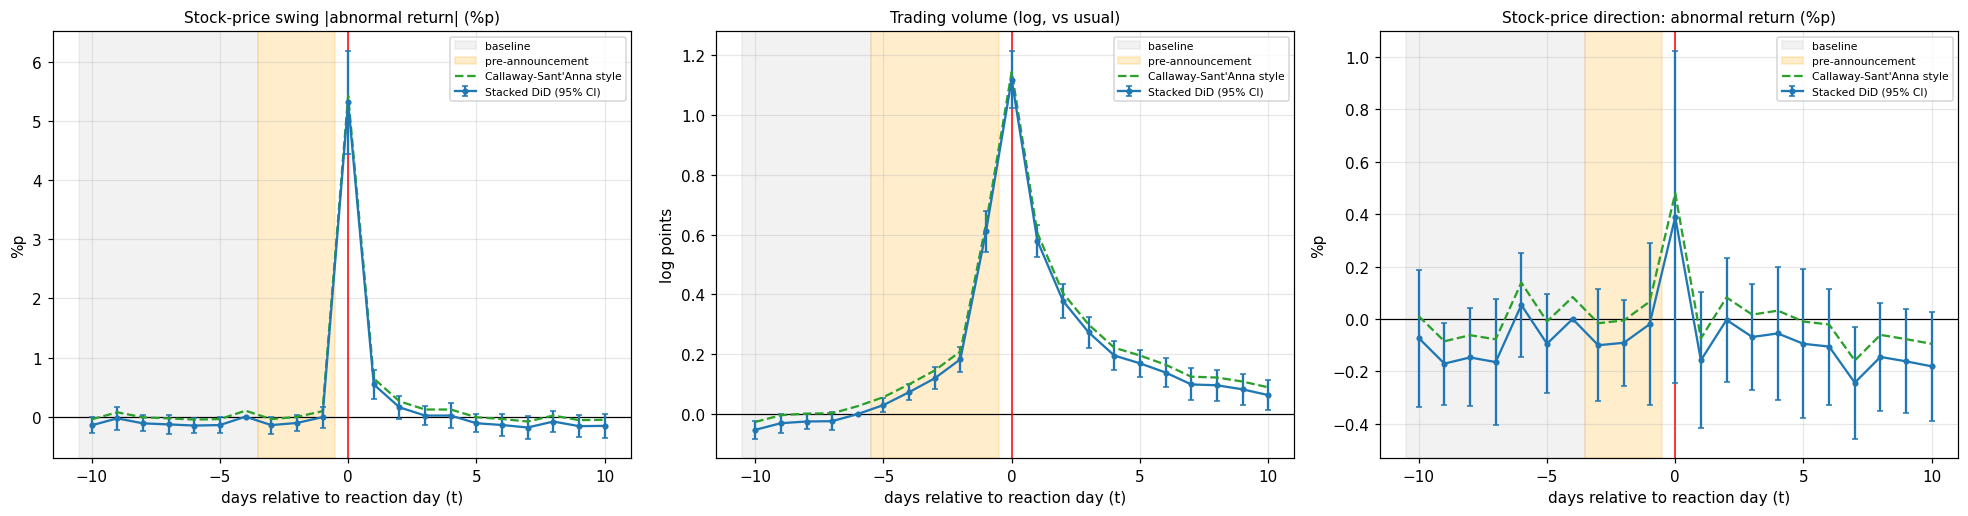

[평행추세 점검] Stock-price swing |abnormal return| (%p): 기준 구간 7일 중 0을 벗어난 날 3일 (적을수록 좋음)
[평행추세 점검] Trading volume (log, vs usual): 기준 구간 5일 중 0을 벗어난 날 2일 (적을수록 좋음)
[평행추세 점검] Stock-price direction: abnormal return (%p): 기준 구간 7일 중 0을 벗어난 날 1일 (적을수록 좋음)


In [21]:
es_ann, cs_ann = {}, {}
for y, w in WIN_ANN.items():
    es_ann[y] = event_study(stack, y, ref_day=w["ref"][1])
    cs_ann[y] = cs_style(stack, y, w["ref"])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, (y, w) in zip(axes, WIN_ANN.items()):
    plot_es(ax, es_ann[y], w["name"], "log points" if y == "vol" else "%p", w["ref"], w["ant"], cs_ann[y])
plt.tight_layout(); savefig("06_announcement_event_study"); plt.show()

for y, w in WIN_ANN.items():
    pre = es_ann[y][es_ann[y]["rel_day"].between(*w["ref"])]
    bad = int(((pre["lo"] > 0) | (pre["hi"] < 0)).sum())
    print(f"[평행추세 점검] {w['name']}: 기준 구간 {len(pre)}일 중 0을 벗어난 날 {bad}일 (적을수록 좋음)")

## 11-4. 결과 ② 구간별 효과와 계산 방법 비교

날짜별이 아니라 **구간별 평균 효과**입니다.

| 효과 | 뜻 |
|---|---|
| 발표 직전 (하루 평균) | 발표 전 며칠 동안 이미 생긴 차이 |
| **반응일** | **반응일 하루의 차이 ← 가장 중요한 숫자** |
| 발표 후 (하루 평균) | 반응일 다음 10거래일 동안 남은 차이 |

**그래프 읽는 법**: 같은 효과를 세 방법으로 계산한 막대입니다. 막대 위 선은 95% 범위입니다.
- Stacked와 Callaway–Sant'Anna 방식이 비슷하면 → 메인 결과를 믿을 수 있습니다.
- 단순 회귀(TWFE)는 발표 직전 효과를 따로 계산하지 않아서 그 막대가 비어 있습니다.
- 거래량은 로그 단위라서, 표 아래에 "몇 배"로 바꾼 값도 출력합니다.

method                                                                  Stacked DiD  Callaway-Sant'Anna style  Naive TWFE
Y                                           effect                                                                       
Stock-price swing |abnormal return| (%p)    pre-announcement (avg/day)        0.016                     0.016         NaN
                                            reaction day (t=0)                5.421                     5.427       5.426
                                            t+1~t+10 (avg/day)                0.092                     0.092       0.094
Trading volume (log, vs usual)              pre-announcement (avg/day)        0.230                     0.230         NaN
                                            reaction day (t=0)                1.145                     1.144       1.106
                                            t+1~t+10 (avg/day)                0.234                     0.234       0.223
Stock-price direction: abnormal return (%p) pre-announcement (avg/day)        0.015                     0.015         NaN
                                            reaction day (t=0)                0.474                     0.480       0.504
                                            t+1~t+10 (avg/day)               -0.036                    -0.036      -0.020

거래량 pre-announcement (avg/day): 대조군 대비 약 1.26배 (95% 범위 1.23 ~ 1.29배)
거래량 reaction day (t=0): 대조군 대비 약 3.14배 (95% 범위 2.85 ~ 3.46배)
거래량 t+1~t+10 (avg/day): 대조군 대비 약 1.26배 (95% 범위 1.21 ~ 1.32배)


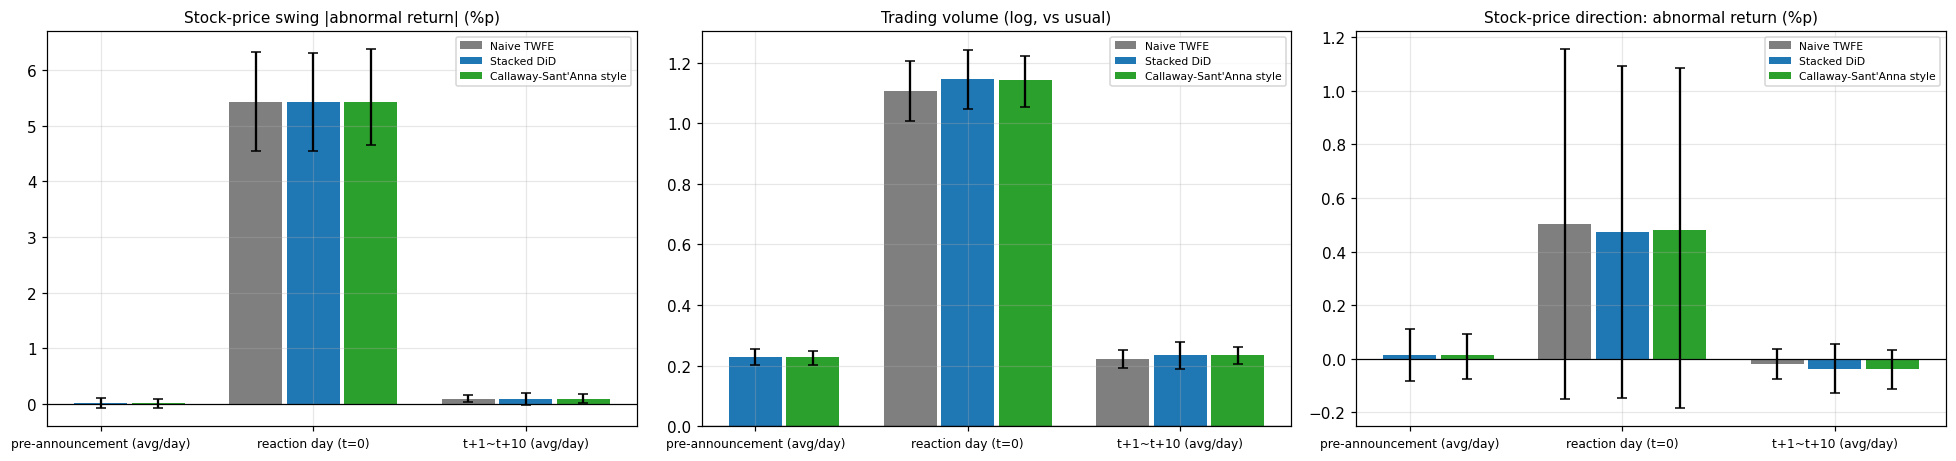

In [22]:
LABELS = {"ant": "pre-announcement (avg/day)", "d0": "reaction day (t=0)", "dpost": f"t+1~t+{WIN} (avg/day)"}
rows = []
for y, w in WIN_ANN.items():
    st = pooled(stack, y, w["ref"], w["ant"]); tw = twfe_naive(y)
    for eff in ["ant", "d0", "dpost"]:
        win = {"ant": w["ant"], "d0": T0_WIN, "dpost": (1, WIN)}[eff]
        rows.append(dict(Y=w["name"], y=y, effect=LABELS[eff], method="Stacked DiD", est=st.loc[eff, "est"], lo=st.loc[eff, "lo"], hi=st.loc[eff, "hi"]))
        e_, l_, h_ = cs_window(cs_ann[y], win)
        rows.append(dict(Y=w["name"], y=y, effect=LABELS[eff], method="Callaway-Sant'Anna style", est=e_, lo=l_, hi=h_))
        if eff in tw.index:
            rows.append(dict(Y=w["name"], y=y, effect=LABELS[eff], method="Naive TWFE", est=tw.loc[eff, "est"], lo=tw.loc[eff, "lo"], hi=tw.loc[eff, "hi"]))
res_ann = pd.DataFrame(rows)
res_ann.to_csv(OUT_DIR / "announcement_results.csv", index=False)
display(res_ann.pivot_table(index=["Y", "effect"], columns="method", values="est", sort=False).round(3))

v = res_ann[(res_ann["y"] == "vol") & (res_ann["method"] == "Stacked DiD")]
for _, r in v.iterrows():
    print(f"거래량 {r['effect']}: 대조군 대비 약 {np.exp(r['est']):.2f}배 (95% 범위 {np.exp(r['lo']):.2f} ~ {np.exp(r['hi']):.2f}배)")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
colors = {"Naive TWFE": "tab:gray", "Stacked DiD": "tab:blue", "Callaway-Sant'Anna style": "tab:green"}
for ax, (y, w) in zip(axes, WIN_ANN.items()):
    sub = res_ann[res_ann["y"] == y]; effs = list(LABELS.values())
    for i, m in enumerate(colors):
        s_ = sub[sub["method"] == m].set_index("effect").reindex(effs)
        x = np.arange(len(effs)) + (i - 1) * 0.27
        ax.bar(x, s_["est"], width=0.25, color=colors[m], label=m)
        ax.errorbar(x, s_["est"], yerr=[s_["est"] - s_["lo"], s_["hi"] - s_["est"]], fmt="none", color="black", capsize=3)
    ax.set_xticks(np.arange(len(effs))); ax.set_xticklabels(effs, fontsize=8)
    ax.axhline(0, color="black", lw=0.8); ax.set_title(w["name"], fontsize=10); ax.legend(fontsize=7)
plt.tight_layout(); savefig("07_announcement_methods"); plt.show()

---
# 12. 서프라이즈 크기 분석

> **질문**: 서프라이즈가 클수록 주가가 더 오르나요?
> **대상**: 실적을 발표한 회사들만 (회사 기준 점수가 계산된 발표)
> **방식**: 점수를 그룹으로 나누지 않고 **숫자 그대로** 넣어서, "점수가 1 올라갈 때마다 주가가 얼마나 더 오르나(기울기)"를 구합니다.

## 12-1. 계산 방법 (연속 처치 DiD)

1. 발표마다 반응일 기준 t−10 ~ t+10의 일별 초과수익률을 줄 세웁니다.
2. 각 발표의 **기준 구간(t−10 ~ t−6)** 평균을 그 발표의 "평소"로 놓습니다. (발표 고정효과)
3. 같은 분기에 발표한 회사들의 같은 날짜(t−3, t=0 등)끼리 비교합니다. 같은 어닝시즌의 공통 분위기를 지우기 위해서입니다. (분기×날짜 고정효과)
4. 그 위에서 "점수 × 구간"의 기울기를 구합니다.

**결과 숫자 세 개**

| 숫자 | 뜻 | 예시 해석 |
|---|---|---|
| 발표 직전 기울기 (t−5 ~ t−1 합계) | 점수가 1 높은 발표는 발표 **전에** 이미 얼마나 더 올라 있었나 | +0.5%p면 "좋은 실적이 미리 새어 나갔을" 가능성 |
| **반응일 기울기 (t=0)** | **점수가 1 높을 때 반응일에 얼마나 더 오르나 ← 핵심** | +2%p면 "점수 +1당 반응일 주가 2%p 더 오름" |
| 발표 후 기울기 (t+1 ~ t+10 합계) | 발표 후에도 점수에 따라 계속 벌어지나 | 플러스면 "좋은 소식 후 계속 오름" |

**왜 이게 DiD인가요?** 각 발표의 "평소" 대비 변화(첫 번째 차이)를, 점수가 다른 발표끼리 비교(두 번째 차이)하기 때문입니다. 약을 1알 먹은 사람과 3알 먹은 사람의 "복용 전 대비 변화"를 비교하는 것과 같습니다.

In [23]:
W_SUR = dict(ref=(-WIN, -6), ant=(-5, -1))

def build_score_panel(events, score_col="score", pre=WIN, post=WIN, shift=0, exclude=()):
    rel = np.arange(-pre, post + 1)
    rows = {k: [] for k in ["event", "ticker", "quarter", "rel_day", "abn_ret", "score"]}
    for x in events.itertuples():
        sc = getattr(x, score_col)
        if pd.isna(sc) or x.ticker in exclude:
            continue
        p = int(x.t0_pos) + shift
        if p - BASE_START < 0 or p + post > T - 1 or not full_prices(col[x.ticker], p, post):
            continue
        if shift != 0 and announces_in(x.ticker, p - pre, p + post):
            continue
        n = len(rel)
        rows["event"].append(np.repeat(x.event_id, n)); rows["ticker"].append(np.repeat(x.ticker, n))
        rows["quarter"].append(np.repeat(str(trading_days[p].to_period("Q")), n))
        rows["rel_day"].append(rel); rows["abn_ret"].append(ABN[p + rel, col[x.ticker]]); rows["score"].append(np.repeat(sc, n))
    return pd.DataFrame({k: np.concatenate(v) for k, v in rows.items()})

def score_pooled(panel, ref, ant, t0=T0_WIN, post=(1, WIN), asym=False):
    d = panel[panel["rel_day"].between(ref[0], post[1])].dropna(subset=["abn_ret"]).copy()
    r = d["rel_day"]; d["qk"] = d["quarter"] + "|" + r.astype(str)
    wins = {"ant": ant, "t0": t0, "post": post}; names = []
    if asym:
        d["s_pos"] = d["score"].clip(lower=0); d["s_neg"] = d["score"].clip(upper=0)
        for side in ["pos", "neg"]:
            for wn, w in wins.items():
                nm = f"{side}_{wn}"; d[nm] = d[f"s_{side}"] * r.between(*w); names.append(nm)
    else:
        for wn, w in wins.items():
            nm = f"s_{wn}"; d[nm] = d["score"] * r.between(*w); names.append(nm)
    fit = pf.feols(f"abn_ret ~ {' + '.join(names)} | event + qk", data=d, vcov={"CRV1": "ticker"})
    out = _tidy(fit, names); out["n_events"] = d["event"].nunique()
    return out

def score_event_study(panel, ref_day):
    d = panel.dropna(subset=["abn_ret"]).copy(); d["qk"] = d["quarter"] + "|" + d["rel_day"].astype(str)
    ks = sorted(k for k in d["rel_day"].unique() if k != ref_day); kmap = {}
    for k in ks:
        nm = f"k_m{-k}" if k < 0 else f"k_p{k}"
        d[nm] = d["score"] * (d["rel_day"] == k); kmap[k] = nm
    fit = pf.feols(f"abn_ret ~ {' + '.join(kmap.values())} | event + qk", data=d, vcov={"CRV1": "ticker"})
    es = _tidy(fit, list(kmap.values())).reset_index(drop=True); es["rel_day"] = ks
    es = pd.concat([es, pd.DataFrame({"rel_day": [ref_day], "est": [0.0], "lo": [0.0], "hi": [0.0]})])
    return es.sort_values("rel_day").reset_index(drop=True), fit, kmap, d["ticker"].nunique()

def cumulative(fit, kmap, start, end, n_clusters):
    coef = fit.coef(); coef.index = [str(i) for i in coef.index]
    names_all = [str(n) for n in fit._coefnames]; V = np.asarray(fit._vcov)
    q = stats.t.ppf(0.975, max(n_clusters - 1, 1))
    ks = [k for k in sorted(kmap) if start <= k <= end]; out = []
    for i in range(len(ks)):
        sel = [names_all.index(kmap[k]) for k in ks[: i + 1]]
        w = np.zeros(len(names_all)); w[sel] = 1
        m = float(coef[[kmap[k] for k in ks[: i + 1]]].sum()); se = float(np.sqrt(w @ V @ w))
        out.append({"rel_day": ks[i], "est": m, "lo": m - q * se, "hi": m + q * se})
    return pd.DataFrame(out)

panel_s = build_score_panel(ev)
print(f"서프라이즈 크기 분석에 쓰는 발표: {panel_s['event'].nunique()}건 / 회사 {panel_s['ticker'].nunique()}개")

서프라이즈 크기 분석에 쓰는 발표: 569건 / 회사 30개


## 12-2. 결과 ① 점수와 반응일 주가의 관계 (산점도)

**그래프가 보여주는 것**: 점 하나 = 발표 하나입니다. 가로 = 회사 기준 점수, 세로 = 반응일 초과수익률(%).
- 회색 점: 개별 발표
- 빨간 점: 보기 쉽게 하려고 점수 순서대로 10묶음으로 나눠 평균낸 것 (**그래프용일 뿐, 분석은 묶지 않은 숫자 그대로 합니다**)
- 파란 선: 전체 경향선

**읽는 법**: 파란 선이 오른쪽 위로 올라가면 "점수가 높을수록 반응일에 더 오른다"는 뜻입니다. 빨간 점들이 선을 따라 고르게 올라가면 관계가 직선에 가깝고, 한쪽에서만 꺾이면 좋은 소식과 나쁜 소식에 반응이 다르다(비대칭)는 신호입니다.

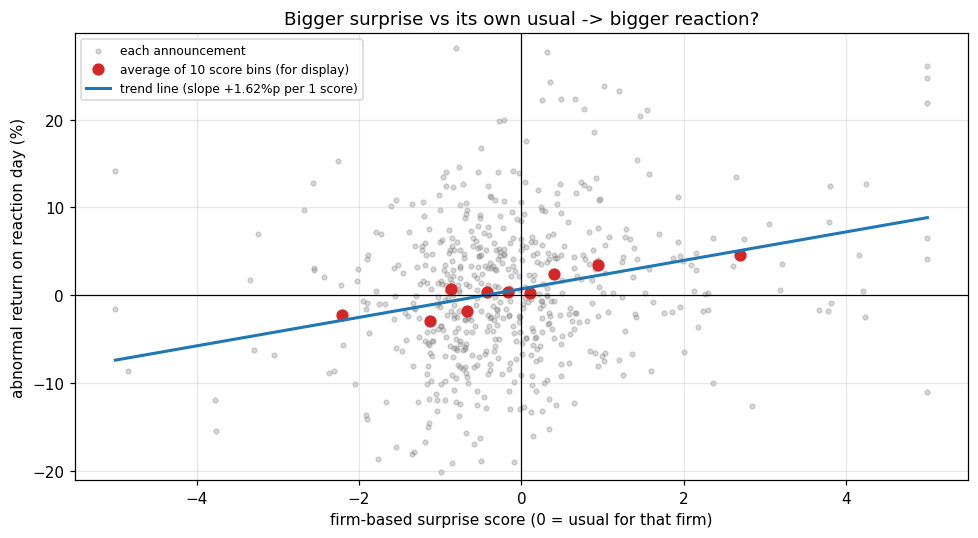

In [24]:
r0 = panel_s[panel_s["rel_day"] == 0].dropna(subset=["abn_ret"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(r0["score"], r0["abn_ret"], s=10, alpha=0.3, color="gray", label="each announcement")
bins = pd.qcut(r0["score"], 10, duplicates="drop")
bm = r0.groupby(bins, observed=True).agg(score=("score", "mean"), ret=("abn_ret", "mean"))
ax.plot(bm["score"], bm["ret"], "o", color="tab:red", ms=7, label="average of 10 score bins (for display)")
b1, b0 = np.polyfit(r0["score"], r0["abn_ret"], 1)
xs = np.linspace(r0["score"].min(), r0["score"].max(), 50)
ax.plot(xs, b0 + b1 * xs, color="tab:blue", lw=2, label=f"trend line (slope {b1:+.2f}%p per 1 score)")
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_ylim(np.nanpercentile(r0["abn_ret"], 1) - 2, np.nanpercentile(r0["abn_ret"], 99) + 2)
ax.set_xlabel("firm-based surprise score (0 = usual for that firm)"); ax.set_ylabel("abnormal return on reaction day (%)")
ax.set_title("Bigger surprise vs its own usual -> bigger reaction?"); ax.legend(fontsize=8)
plt.tight_layout(); savefig("08_score_scatter"); plt.show()

## 12-3. 결과 ② 날짜별 기울기와 누적 기울기

**왼쪽 그래프 (날짜별 기울기)**: 날마다 "점수가 1 높은 발표가 그날 얼마나 더 올랐나"입니다. 기준일은 t−6입니다.
- 회색 구간(기준 구간)의 점들이 0 근처면 → 발표 전 평소에는 점수와 상관없이 비슷하게 움직였다 (평행추세 OK)
- 주황 구간(발표 직전)에서 점들이 0 위에 있으면 → 점수가 높은 발표는 **발표 전부터 이미 오르고 있었다** (정보가 미리 반영됨)
- 반응일(빨간 선)의 점 = 반응일 기울기

**오른쪽 그래프 (누적 기울기)**: t−5부터 날짜별 기울기를 하루씩 더해간 값입니다. 색칠된 띠는 95% 범위입니다.
- t=−1의 높이 = 발표 직전 5일 동안 미리 벌어진 양
- t=0에서 뛰는 높이 = 반응일 효과
- t=+10의 높이 = 전부 합친 효과 (점수 1당)
- 띠가 0 선 위에 완전히 떠 있으면 "우연이 아니다"라고 볼 수 있습니다.

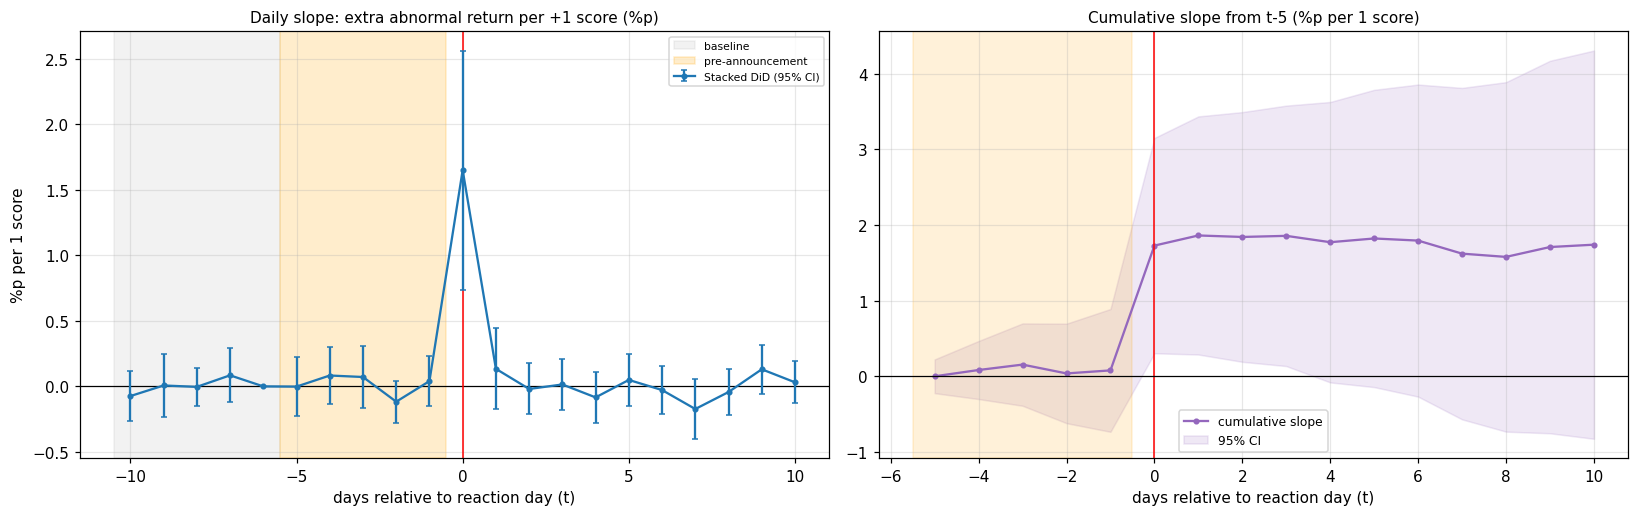

In [25]:
es_s, fit_s, kmap_s, ncl_s = score_event_study(panel_s, ref_day=W_SUR["ref"][1])
cum_s = cumulative(fit_s, kmap_s, W_SUR["ant"][0], WIN, ncl_s)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
plot_es(axes[0], es_s, "Daily slope: extra abnormal return per +1 score (%p)", "%p per 1 score", W_SUR["ref"], W_SUR["ant"])
ax = axes[1]
ax.plot(cum_s["rel_day"], cum_s["est"], "o-", ms=3, color="tab:purple", label="cumulative slope")
ax.fill_between(cum_s["rel_day"], cum_s["lo"], cum_s["hi"], color="tab:purple", alpha=0.15, label="95% CI")
ax.axvline(0, color="red", lw=1); ax.axhline(0, color="black", lw=0.8)
ax.axvspan(W_SUR["ant"][0] - 0.5, W_SUR["ant"][1] + 0.5, color="orange", alpha=0.15)
ax.set_title(f"Cumulative slope from t{W_SUR['ant'][0]} (%p per 1 score)", fontsize=10)
ax.set_xlabel("days relative to reaction day (t)"); ax.legend(fontsize=8)
plt.tight_layout(); savefig("09_score_event_study"); plt.show()

## 12-4. 결과 ③ 숫자로 정리 + 좋은 쪽과 나쁜 쪽 비교

**표 1 (메인)**: 점수 1당 효과입니다.
- 발표 직전과 발표 후는 "하루 평균 × 일수"로 바꿔서 **구간 합계**로 보여줍니다.

**표 2 / 막대 그래프 (좋은 쪽 vs 나쁜 쪽)**: 점수가 0보다 큰 발표들과 0보다 작은 발표들의 **반응일 기울기를 따로** 구합니다.
- 플러스 쪽 기울기: 평소보다 크게 넘길 때, 점수 1 더 높아질 때마다 얼마나 더 오르나
- 마이너스 쪽 기울기: 평소보다 덜 넘길 때, 점수 1 더 낮아질 때마다 얼마나 더 떨어지나
- **두 막대 높이가 비슷하면** 좋은 소식과 나쁜 소식에 똑같이 민감한 것, **한쪽만 크면** 비대칭입니다. (이전 파일럿에선 좋은 쪽만 크게 반응했습니다)

표 1. 점수 1당 효과 (%p)


,effect,est,lo,hi,significant,n_events
0,pre-announcement t-5~t-1 (sum),0.063,-0.441,0.566,False,569
1,reaction day t=0,1.648,0.747,2.549,True,569
2,after t+1~t+10 (sum),-0.015,-0.789,0.758,False,569


표 2. 반응일 기울기: 플러스 쪽 vs 마이너스 쪽 (%p per 1 score)


,side,est,lo,hi
0,positive score (beat more than usual),1.746,0.598,2.894
1,negative score (beat less than usual),1.515,-0.278,3.307


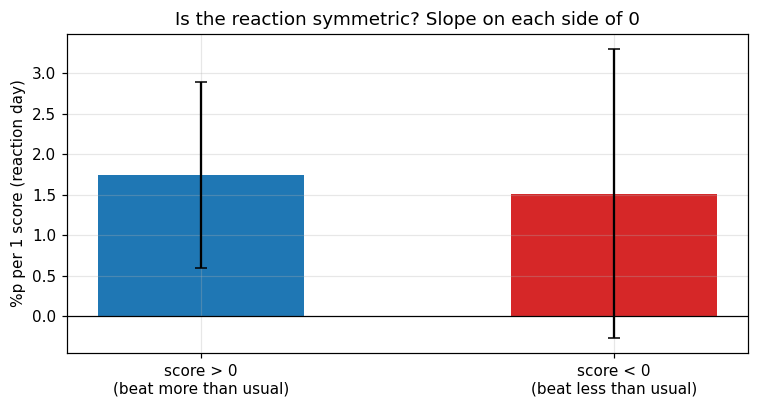

In [26]:
sp = score_pooled(panel_s, W_SUR["ref"], W_SUR["ant"])
n_ant = W_SUR["ant"][1] - W_SUR["ant"][0] + 1
table_s = pd.DataFrame({
    "effect": [f"pre-announcement t{W_SUR['ant'][0]}~t-1 (sum)", "reaction day t=0", f"after t+1~t+{WIN} (sum)"],
    "est": [sp.loc["s_ant", "est"] * n_ant, sp.loc["s_t0", "est"], sp.loc["s_post", "est"] * WIN],
    "lo": [sp.loc["s_ant", "lo"] * n_ant, sp.loc["s_t0", "lo"], sp.loc["s_post", "lo"] * WIN],
    "hi": [sp.loc["s_ant", "hi"] * n_ant, sp.loc["s_t0", "hi"], sp.loc["s_post", "hi"] * WIN],
})
table_s["significant"] = (table_s["lo"] > 0) | (table_s["hi"] < 0)
table_s["n_events"] = int(sp["n_events"].iloc[0])
table_s.to_csv(OUT_DIR / "surprise_results.csv", index=False)
print("표 1. 점수 1당 효과 (%p)"); display(table_s.round(3))

sa = score_pooled(panel_s, W_SUR["ref"], W_SUR["ant"], asym=True)
asym = pd.DataFrame({"side": ["positive score (beat more than usual)", "negative score (beat less than usual)"],
                     "est": [sa.loc["pos_t0", "est"], sa.loc["neg_t0", "est"]],
                     "lo": [sa.loc["pos_t0", "lo"], sa.loc["neg_t0", "lo"]],
                     "hi": [sa.loc["pos_t0", "hi"], sa.loc["neg_t0", "hi"]]})
print("표 2. 반응일 기울기: 플러스 쪽 vs 마이너스 쪽 (%p per 1 score)"); display(asym.round(3))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar([0, 1], asym["est"], color=["tab:blue", "tab:red"], width=0.5)
ax.errorbar([0, 1], asym["est"], yerr=[asym["est"] - asym["lo"], asym["hi"] - asym["est"]], fmt="none", color="black", capsize=4)
ax.set_xticks([0, 1]); ax.set_xticklabels(["score > 0\n(beat more than usual)", "score < 0\n(beat less than usual)"])
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("%p per 1 score (reaction day)")
ax.set_title("Is the reaction symmetric? Slope on each side of 0")
plt.tight_layout(); savefig("10_score_asymmetry"); plt.show()

---
# 13. 검증 — 결과를 믿을 수 있나요?

**한 줄로**: "조건을 이렇게 저렇게 바꿔도 결과가 똑같이 나오나?"를 확인합니다.
다이어트 약 실험으로 비유하면, 운동한 사람을 빼도, 계절을 바꿔도 효과가 같은지 보고, 가짜 약(설탕)을 먹이면 효과가 0인지 확인하는 것입니다.

## 13-1. 발표 효과 분석 검증

| # | 바꾸는 조건 | 왜 확인하나 |
|---|---|---|
| 1 | (기본) | 기준 |
| 2 | 구간 안에 시장 충격일이 낀 발표 제외 | 시장이 크게 출렁인 날 때문에 결과가 나온 건 아닌지 |
| 3 | 발표 시각이 섞인 회사 제외 | 시각 기록 오류 때문은 아닌지 |
| 4 | 날짜 오류가 의심되는 발표 제외 | 날짜 오류 때문은 아닌지 |
| 5 | 대조군을 **다른 세부업종 묶음**으로만 | 같은 업종 회사가 같이 움직여서 비교가 오염된 건 아닌지 (SUTVA 문제) |
| 6 | 구간을 ±5거래일로 | 구간 길이에 따라 달라지는지 |
| 7 | 구간을 20거래일 전 ~ 10거래일 후로 (이전 파일럿 방식) | 10거래일 구간의 한계(아래 설명)가 얼마나 영향을 주는지 |
| 8 | **가짜 발표일**: 실제 반응일 31거래일(약 45일) 전 | 아무 일 없는 날엔 효과가 0이어야 정상 |

**7번이 왜 필요한가요?** 효과는 "기준 구간(평소) 대비"로 계산합니다. 그런데 거래량은 발표 2~3주 전부터 서서히 늘어납니다. 10거래일 구간에서는 "평소"로 잡은 날(t−10 ~ t−6)이 이미 조금 들떠 있을 수 있어서, 거래량 효과가 실제보다 **작게** 잡힐 수 있습니다. 20거래일 버전과 비교하면 그 차이가 얼마나 되는지 알 수 있습니다.

**포레스트 그래프 읽는 법**: 점 = 반응일 효과, 가로 선 = 95% 범위, 파란 점선 = 기본 결과
- 1~7번 점이 기본 결과 근처에 모여 있고 0에서 멀면 → 결과가 튼튼합니다.
- 8번(빨강)은 가로 선이 0을 지나야 정상입니다.

1 Main: 미니 실험 569개
2 Excl. market-shock events: 미니 실험 480개
3 Excl. mixed-timing firms: 미니 실험 550개
4 Excl. misaligned events: 미니 실험 531개
5 Controls: different group only: 미니 실험 569개
6 Window +-5: 미니 실험 569개
7 Window -20~+10 (old pilot): 미니 실험 569개
8 Placebo (31 days earlier): 미니 실험 569개


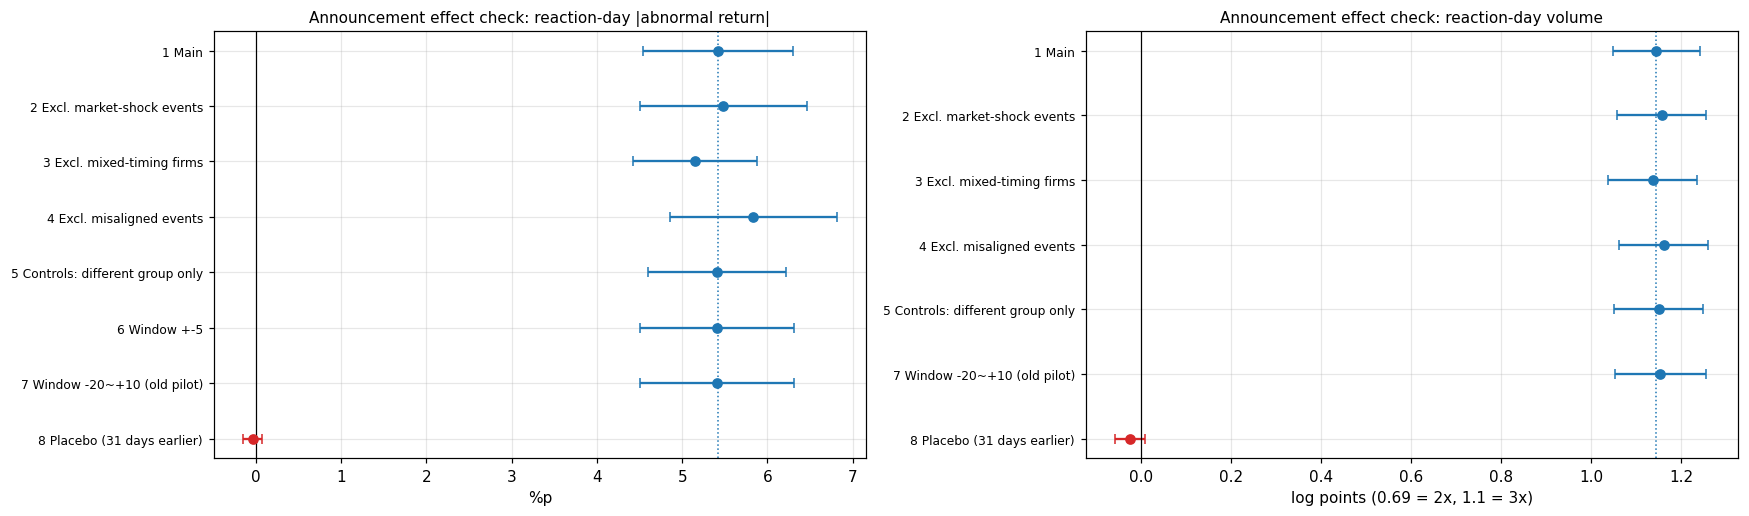

y,abs_ret,vol
spec,,
1 Main,5.421,1.145
2 Excl. market-shock events,5.484,1.156
3 Excl. mixed-timing firms,5.150,1.137
4 Excl. misaligned events,5.835,1.161
5 Controls: different group only,5.408,1.150
6 Window +-5,5.411,NaN
7 Window -20~+10 (old pilot),5.403,1.154
8 Placebo (31 days earlier),-0.037,-0.025


In [27]:
specs_ann = [("1 Main", dict()),
             ("2 Excl. market-shock events", dict(events=ev[~ev["has_market_shock"]])),
             ("3 Excl. mixed-timing firms", dict(exclude=tuple(MIXED_TIMING)) if MIXED_TIMING else None),
             ("4 Excl. misaligned events", dict(events=ev[~ev["misaligned"]])),
             ("5 Controls: different group only", dict(diff_group=True)),
             ("6 Window +-5", dict(pre=5, post=5)),
             ("7 Window -20~+10 (old pilot)", dict(pre=20, post=10)),
             ("8 Placebo (31 days earlier)", dict(shift=-PLACEBO_SHIFT))]
rob_ann = []
for name, kw in specs_ann:
    if kw is None:
        continue
    kw = dict(kw); evs = kw.pop("events", ev); pre, post = kw.get("pre", WIN), kw.get("post", WIN)
    st_, nc_ = build_announcement_stack(evs, **kw)
    for y in ["abs_ret", "vol"]:
        w = WIN_ANN[y]; ref = (-pre, w["ref"][1])
        if ref[0] > ref[1]:
            rob_ann.append(dict(spec=name, y=y, est=np.nan, lo=np.nan, hi=np.nan, n=len(nc_))); continue
        pr = pooled(st_, y, ref, w["ant"], post=(1, post))
        rob_ann.append(dict(spec=name, y=y, est=pr.loc["d0", "est"], lo=pr.loc["d0", "lo"], hi=pr.loc["d0", "hi"], n=len(nc_)))
    print(f"{name}: 미니 실험 {len(nc_)}개")
rob_ann = pd.DataFrame(rob_ann)
rob_ann.to_csv(OUT_DIR / "check_announcement_robustness.csv", index=False)

def forest(ax, df, title, xlabel):
    df = df.dropna(subset=["est"]).reset_index(drop=True); yy = np.arange(len(df))[::-1]
    for yi, (_, r) in zip(yy, df.iterrows()):
        c = "tab:red" if "Placebo" in r["spec"] else "tab:blue"
        ax.errorbar(r["est"], yi, xerr=[[r["est"] - r["lo"]], [r["hi"] - r["est"]]], fmt="o", color=c, capsize=3)
    m = df.loc[df["spec"].str.startswith("1"), "est"]
    if len(m):
        ax.axvline(m.iloc[0], color="tab:blue", ls=":", lw=1)
    ax.axvline(0, color="black", lw=0.8); ax.set_yticks(yy); ax.set_yticklabels(df["spec"], fontsize=8)
    ax.set_title(title, fontsize=10); ax.set_xlabel(xlabel)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
forest(axes[0], rob_ann[rob_ann["y"] == "abs_ret"], "Announcement effect check: reaction-day |abnormal return|", "%p")
forest(axes[1], rob_ann[rob_ann["y"] == "vol"], "Announcement effect check: reaction-day volume", "log points (0.69 = 2x, 1.1 = 3x)")
plt.tight_layout(); savefig("11_announcement_checks"); plt.show()
display(rob_ann.pivot_table(index="spec", columns="y", values="est").round(3))

**가짜 발표일을 7개로 늘려서 다시 확인**

가짜 날짜 하나만 보면 우연히 "의미 있음"이 나올 수 있습니다. 95% 범위는 원래 **20번 중 1번은 우연히 0을 벗어나도록** 만들어진 기준이기 때문입니다. 그래서 실제 반응일 25, 27, 29, 31, 33, 35, 37거래일 전을 각각 가짜 발표일로 잡고 다 돌려봅니다.

**읽는 법**
- 7개 점이 0 주변에 흩어져 있고 0을 벗어나는 게 0~1개면 → 정상 (우연 수준)
- 1~2개가 벗어나도 **방향이 제각각(하나는 +, 하나는 −)**이면 우연일 가능성이 큽니다.
- 대부분이 **한쪽 방향으로** 0을 벗어나면 → 방법이나 데이터에 문제가 있다는 신호입니다.
- 그래프 제목에 실제 효과 크기를 적어 두었습니다. 가짜 날짜의 숫자가 실제 효과보다 훨씬 작으면 됩니다.

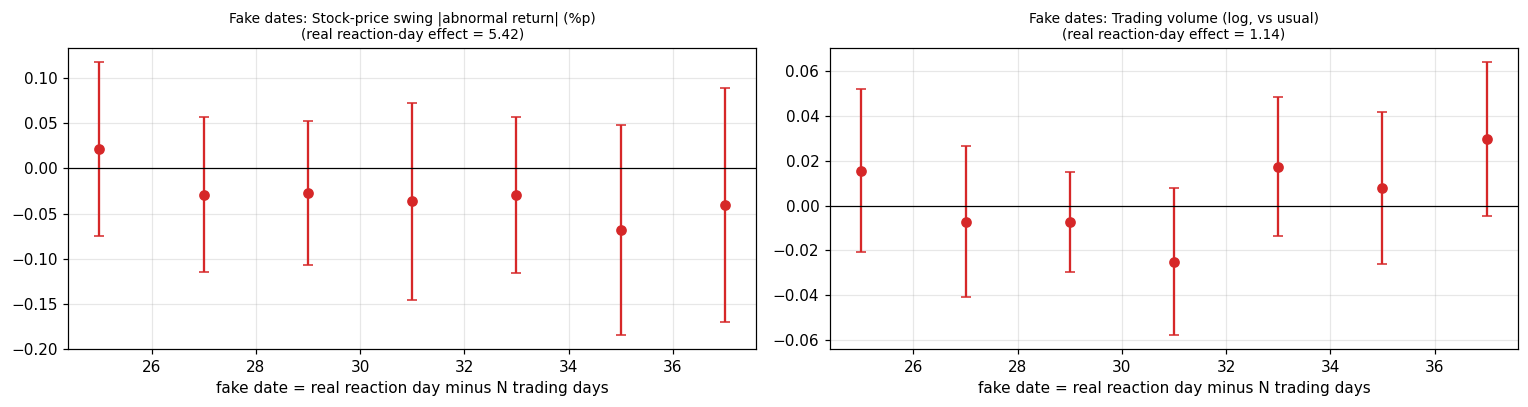

가짜 날짜 7개 중 '의미 있음' 개수: {'abs_ret': 0, 'vol': 0}


In [28]:
plc_rows = []
for s_ in range(25, 38, 2):
    st_, nc_ = build_announcement_stack(ev, shift=-s_)
    for y in ["abs_ret", "vol"]:
        w = WIN_ANN[y]; pr = pooled(st_, y, w["ref"], w["ant"])
        plc_rows.append(dict(shift=s_, y=y, est=pr.loc["d0", "est"], lo=pr.loc["d0", "lo"], hi=pr.loc["d0", "hi"]))
plc_ann = pd.DataFrame(plc_rows); plc_ann["significant"] = (plc_ann["lo"] > 0) | (plc_ann["hi"] < 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, y in zip(axes, ["abs_ret", "vol"]):
    d = plc_ann[plc_ann["y"] == y]; real = rob_ann[(rob_ann["spec"].str.startswith("1")) & (rob_ann["y"] == y)]["est"].iloc[0]
    ax.errorbar(d["shift"], d["est"], yerr=[d["est"] - d["lo"], d["hi"] - d["est"]], fmt="o", color="tab:red", capsize=3)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Fake dates: {WIN_ANN[y]['name']}\n(real reaction-day effect = {real:.2f})", fontsize=9)
    ax.set_xlabel("fake date = real reaction day minus N trading days")
plt.tight_layout(); savefig("12_announcement_placebo_multi"); plt.show()
print("가짜 날짜 7개 중 '의미 있음' 개수:", plc_ann.groupby("y")["significant"].sum().to_dict())

## 13-2. 서프라이즈 크기 분석 검증

| # | 바꾸는 조건 | 왜 확인하나 |
|---|---|---|
| 1 | (기본) | 기준 |
| 2 | 반응 구간을 t=0 ~ t+1 이틀 합계로 | 날짜가 하루 어긋난 발표가 있어도 결과가 같은지 |
| 3 | 시장 충격일이 낀 발표 제외 | 시장 급변 때문은 아닌지 |
| 4 | 날짜 오류 의심 발표 제외 | 날짜 오류 때문은 아닌지 |
| 5 | 발표 시각이 섞인 회사 제외 | 시각 기록 오류 때문은 아닌지 |
| 6 | **시장 전체 기준 점수**로 바꿔서 (회사 평소를 고려하지 않음) | 회사 기준 점수가 정말 더 잘 설명하는지 비교 |
| 7 | 구간을 20거래일 전 ~ 10거래일 후로 | 10거래일 구간의 한계 확인 |
| 8 | **가짜 발표일** (31거래일 전) | 가짜 날짜에선 기울기가 0이어야 정상 |

**6번 해석**: 1번(회사 기준)과 6번(시장 기준)의 기울기를 비교합니다. 둘 다 점수 1 = 표준편차 1만큼이라 크기를 비교할 수 있습니다. 회사 기준 기울기가 더 크거나 범위가 더 좁으면, "시장은 그 회사의 평소 실력 대비로 반응한다"는 근거가 됩니다.

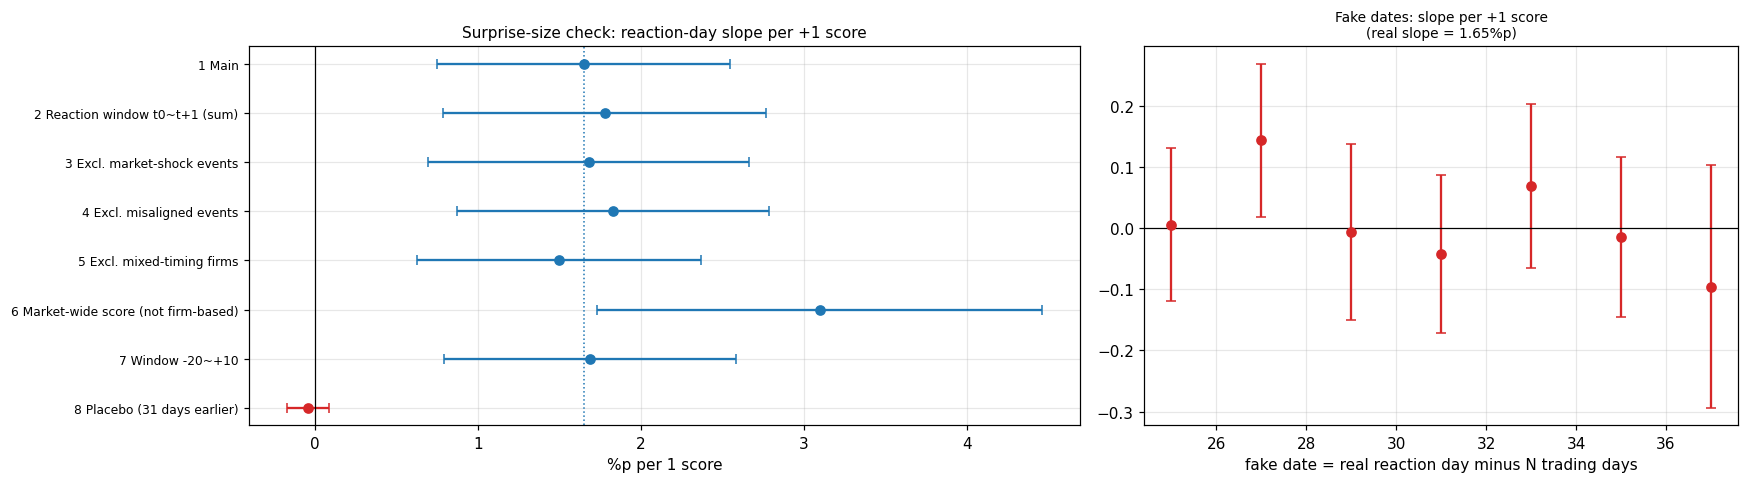

,spec,est,lo,hi,n
0,1 Main,1.648,0.747,2.549,569
1,2 Reaction window t0~t+1 (sum),1.779,0.789,2.770,569
2,3 Excl. market-shock events,1.679,0.695,2.663,480
3,4 Excl. misaligned events,1.828,0.871,2.786,531
4,5 Excl. mixed-timing firms,1.497,0.627,2.368,550
5,6 Market-wide score (not firm-based),3.096,1.728,4.464,569
6,7 Window -20~+10,1.688,0.794,2.581,569
7,8 Placebo (31 days earlier),-0.042,-0.171,0.086,569


가짜 날짜 7개 중 '의미 있음' 개수: 1


In [29]:
scored = ev[ev["score"].notna()]
specs_s = [("1 Main", dict()),
           ("2 Reaction window t0~t+1 (sum)", dict(t0=(0, 1))),
           ("3 Excl. market-shock events", dict(events=scored[~scored["has_market_shock"]])),
           ("4 Excl. misaligned events", dict(events=scored[~scored["misaligned"]])),
           ("5 Excl. mixed-timing firms", dict(exclude=tuple(MIXED_TIMING)) if MIXED_TIMING else None),
           ("6 Market-wide score (not firm-based)", dict(score_col="score_market")),
           ("7 Window -20~+10", dict(pre=20)),
           ("8 Placebo (31 days earlier)", dict(shift=-PLACEBO_SHIFT))]
rob_s = []
for name, kw in specs_s:
    if kw is None:
        continue
    kw = dict(kw); evs = kw.pop("events", scored); t0w = kw.pop("t0", T0_WIN)
    pnl = build_score_panel(evs, **kw)
    ref = (-kw.get("pre", WIN), W_SUR["ref"][1])
    sp_ = score_pooled(pnl, ref, W_SUR["ant"], t0=t0w, post=(t0w[1] + 1, WIN))
    k = t0w[1] - t0w[0] + 1
    rob_s.append(dict(spec=name, est=sp_.loc["s_t0", "est"] * k, lo=sp_.loc["s_t0", "lo"] * k, hi=sp_.loc["s_t0", "hi"] * k,
                      n=int(sp_["n_events"].iloc[0])))
rob_s = pd.DataFrame(rob_s)
rob_s.to_csv(OUT_DIR / "check_surprise_robustness.csv", index=False)

plc_s = []
for s_ in range(25, 38, 2):
    sp_ = score_pooled(build_score_panel(scored, shift=-s_), W_SUR["ref"], W_SUR["ant"])
    plc_s.append(dict(shift=s_, est=sp_.loc["s_t0", "est"], lo=sp_.loc["s_t0", "lo"], hi=sp_.loc["s_t0", "hi"]))
plc_s = pd.DataFrame(plc_s); plc_s["significant"] = (plc_s["lo"] > 0) | (plc_s["hi"] < 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})
forest(axes[0], rob_s, "Surprise-size check: reaction-day slope per +1 score", "%p per 1 score")
axes[1].errorbar(plc_s["shift"], plc_s["est"], yerr=[plc_s["est"] - plc_s["lo"], plc_s["hi"] - plc_s["est"]], fmt="o", color="tab:red", capsize=3)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"Fake dates: slope per +1 score\n(real slope = {rob_s.iloc[0]['est']:.2f}%p)", fontsize=9)
axes[1].set_xlabel("fake date = real reaction day minus N trading days")
plt.tight_layout(); savefig("13_surprise_checks"); plt.show()
display(rob_s.round(3))
print("가짜 날짜 7개 중 '의미 있음' 개수:", int(plc_s["significant"].sum()))

---
# 14. 최종 요약과 결과 저장

아래 셀이 핵심 결과를 **문장으로** 정리해 줍니다. 그대로 팀 공유나 발표 자료에 옮기시면 됩니다.
"95% 범위"가 0을 포함하지 않으면 "의미 있음(우연이라고 보기 어려움)"으로 표시됩니다.

`results_섹터이름/team_summary.csv`에는 **섹터끼리 비교할 핵심 숫자**가 한 표로 저장됩니다. 다른 팀원 결과와 합칠 때 이 파일을 쓰시면 됩니다.

In [30]:
def fmt(est, lo, hi, unit="%p"):
    sig = "의미 있음" if (lo > 0 or hi < 0) else "0과 구분 안 됨"
    return f"{est:+.2f}{unit} (95% 범위 {lo:+.2f} ~ {hi:+.2f}, {sig})"

g = lambda y, eff, m: res_ann[(res_ann["y"] == y) & (res_ann["effect"] == LABELS[eff]) & (res_ann["method"] == m)].iloc[0]
a0, c0, t0_ = g("abs_ret", "d0", "Stacked DiD"), g("abs_ret", "d0", "Callaway-Sant'Anna style"), g("abs_ret", "d0", "Naive TWFE")
v0, va, d0_ = g("vol", "d0", "Stacked DiD"), g("vol", "ant", "Stacked DiD"), g("abn_ret", "d0", "Stacked DiD")
rb = rob_ann[(rob_ann["y"] == "abs_ret") & ~rob_ann["spec"].str.contains("Placebo|-20", regex=True)].dropna(subset=["est"])
p_a = rob_ann[(rob_ann["y"] == "abs_ret") & rob_ann["spec"].str.contains("Placebo")].iloc[0]
w20 = rob_ann[rob_ann["spec"].str.contains("-20")].set_index("y")
main = rob_ann[rob_ann["spec"].str.startswith("1")].set_index("y")
s_ant, s_t0, s_post = table_s.iloc[0], table_s.iloc[1], table_s.iloc[2]
rs = rob_s[~rob_s["spec"].str.contains("Placebo|Market-wide|-20", regex=True)]
p_s = rob_s[rob_s["spec"].str.contains("Placebo")].iloc[0]
mk = rob_s[rob_s["spec"].str.contains("Market-wide")].iloc[0]

lines = [
    f"[{SECTOR_NAME}] 회사 {N}개, 분석 발표 {len(ev)}건, 기간 {EVENT_START} ~ {EVENT_END}, 구간 반응일 ±{WIN}거래일",
    "",
    "■ 발표 효과 분석 (발표한 회사 vs 그 시기 발표 없는 회사)",
    f"  - 미니 실험 {len(nctrl)}개, 실험당 대조군 평균 {nctrl.mean():.1f}개",
    f"  - 반응일 주가 흔들림: {fmt(a0['est'], a0['lo'], a0['hi'])}",
    f"    (같은 효과: Callaway-Sant'Anna 방식 {c0['est']:+.2f}%p, 단순 회귀 {t0_['est']:+.2f}%p)",
    f"  - 반응일 거래량: 대조군 대비 약 {np.exp(v0['est']):.2f}배 ({fmt(v0['est'], v0['lo'], v0['hi'], ' log')})",
    f"  - 발표 직전 거래량: 하루 평균 약 {np.exp(va['est']):.2f}배 ({fmt(va['est'], va['lo'], va['hi'], ' log')})",
    f"  - 반응일 주가 방향 (평균, 0 근처가 정상): {fmt(d0_['est'], d0_['lo'], d0_['hi'])}",
    f"  - 검증 {len(rb)}개 버전의 반응일 주가 흔들림: {rb['est'].min():.2f} ~ {rb['est'].max():.2f}%p (모두 의미 있음: {'예' if (rb['lo'] > 0).all() else '아니오'})",
    f"  - 20거래일 구간 버전: 주가 흔들림 {w20.loc['abs_ret', 'est']:+.2f}%p (10일 {main.loc['abs_ret', 'est']:+.2f}), "
    f"거래량 {np.exp(w20.loc['vol', 'est']):.2f}배 (10일 {np.exp(main.loc['vol', 'est']):.2f}배)",
    f"  - 가짜 발표일: {fmt(p_a['est'], p_a['lo'], p_a['hi'])} / 7개 날짜 중 의미 있음 "
    f"{int(plc_ann[plc_ann['y'] == 'abs_ret']['significant'].sum())}개(주가), {int(plc_ann[plc_ann['y'] == 'vol']['significant'].sum())}개(거래량)",
    "",
    "■ 서프라이즈 크기 분석 (발표한 회사끼리, 회사 기준 점수 그대로)",
    f"  - 분석 발표 {int(s_t0['n_events'])}건",
    f"  - 반응일 기울기: 점수 1당 {fmt(s_t0['est'], s_t0['lo'], s_t0['hi'])}",
    f"  - 발표 직전 5일 합계 기울기: 점수 1당 {fmt(s_ant['est'], s_ant['lo'], s_ant['hi'])}",
    f"  - 발표 후 {WIN}일 합계 기울기: 점수 1당 {fmt(s_post['est'], s_post['lo'], s_post['hi'])}",
    f"  - 좋은 쪽 vs 나쁜 쪽 반응일 기울기: 플러스 쪽 {asym.iloc[0]['est']:+.2f}%p, 마이너스 쪽 {asym.iloc[1]['est']:+.2f}%p",
    f"  - 시장 전체 기준 점수로 바꾸면: 점수 1당 {fmt(mk['est'], mk['lo'], mk['hi'])}",
    f"  - 검증 {len(rs)}개 버전의 반응일 기울기: {rs['est'].min():.2f} ~ {rs['est'].max():.2f}%p",
    f"  - 가짜 발표일: {fmt(p_s['est'], p_s['lo'], p_s['hi'])} / 7개 날짜 중 의미 있음 {int(plc_s['significant'].sum())}개",
]
summary_text = "\n".join(lines); print(summary_text)
(OUT_DIR / "summary.txt").write_text(summary_text, encoding="utf-8")

team = pd.DataFrame([
    dict(sector=SECTOR_NAME, analysis="announcement", metric="reaction-day |abnormal return| (%p)", est=a0["est"], lo=a0["lo"], hi=a0["hi"], n=len(nctrl)),
    dict(sector=SECTOR_NAME, analysis="announcement", metric="reaction-day volume (x times)", est=np.exp(v0["est"]), lo=np.exp(v0["lo"]), hi=np.exp(v0["hi"]), n=len(nctrl)),
    dict(sector=SECTOR_NAME, analysis="announcement", metric="pre-announcement volume (x times/day)", est=np.exp(va["est"]), lo=np.exp(va["lo"]), hi=np.exp(va["hi"]), n=len(nctrl)),
    dict(sector=SECTOR_NAME, analysis="surprise", metric="reaction-day slope per +1 score (%p)", est=s_t0["est"], lo=s_t0["lo"], hi=s_t0["hi"], n=int(s_t0["n_events"])),
    dict(sector=SECTOR_NAME, analysis="surprise", metric="pre-announcement slope, 5-day sum (%p)", est=s_ant["est"], lo=s_ant["lo"], hi=s_ant["hi"], n=int(s_t0["n_events"])),
])
team.to_csv(OUT_DIR / "team_summary.csv", index=False)
print("\n저장된 파일:", sorted(p.name for p in OUT_DIR.iterdir()))

[IT] 회사 30개, 분석 발표 569건, 기간 2022-01-01 ~ 2026-10-07, 구간 반응일 ±10거래일

■ 발표 효과 분석 (발표한 회사 vs 그 시기 발표 없는 회사)
  - 미니 실험 569개, 실험당 대조군 평균 15.8개
  - 반응일 주가 흔들림: +5.42%p (95% 범위 +4.54 ~ +6.30, 의미 있음)
    (같은 효과: Callaway-Sant'Anna 방식 +5.43%p, 단순 회귀 +5.43%p)
  - 반응일 거래량: 대조군 대비 약 3.14배 (+1.14 log (95% 범위 +1.05 ~ +1.24, 의미 있음))
  - 발표 직전 거래량: 하루 평균 약 1.26배 (+0.23 log (95% 범위 +0.20 ~ +0.26, 의미 있음))
  - 반응일 주가 방향 (평균, 0 근처가 정상): +0.47%p (95% 범위 -0.15 ~ +1.09, 0과 구분 안 됨)
  - 검증 6개 버전의 반응일 주가 흔들림: 5.15 ~ 5.84%p (모두 의미 있음: 예)
  - 20거래일 구간 버전: 주가 흔들림 +5.40%p (10일 +5.42), 거래량 3.17배 (10일 3.14배)
  - 가짜 발표일: -0.04%p (95% 범위 -0.15 ~ +0.07, 0과 구분 안 됨) / 7개 날짜 중 의미 있음 0개(주가), 0개(거래량)

■ 서프라이즈 크기 분석 (발표한 회사끼리, 회사 기준 점수 그대로)
  - 분석 발표 569건
  - 반응일 기울기: 점수 1당 +1.65%p (95% 범위 +0.75 ~ +2.55, 의미 있음)
  - 발표 직전 5일 합계 기울기: 점수 1당 +0.06%p (95% 범위 -0.44 ~ +0.57, 0과 구분 안 됨)
  - 발표 후 10일 합계 기울기: 점수 1당 -0.02%p (95% 범위 -0.79 ~ +0.76, 0과 구분 안 됨)
  - 좋은 쪽 vs 나쁜 쪽 반응일 기울기: 플러스 쪽 +1.75%p, 마이너스 쪽 +1.51%p
  - 시장 전체 기준 점수로 바꾸면: 점수

# 15. 한계와 주의할 점 (발표 때 같이 말씀하실 것)

1. **10거래일 구간의 한계**
   - 거래량은 발표 2-3주 전부터, 좋은 소식의 주가는 8-10일 전부터 움직이기 시작합니다. 10거래일 구간에서는 "평소"로 잡은 기준 구간이 이미 조금 들떠 있을 수 있어서, 거래량 효과와 발표 직전 효과가 **실제보다 작게** 잡힐 수 있습니다.
   - 반대로, 대조군 회사가 구간 바로 앞(11~20거래일 전)에 자기 실적을 발표했다면, 그 회사의 거래량이 기준 구간까지 아직 들떠 있을 수 있습니다. 거래량은 발표 후 2주 가까이 높게 유지되기 때문입니다. 이 경우 거래량 효과가 아주 조금 **크게** 잡힐 수 있습니다. 가짜 발표일 검증에서 거래량이 0보다 아주 살짝 크게 나온다면 이 때문일 가능성이 큽니다.
   - 두 영향의 크기는 검증 7번(20거래일 버전)과 비교해서 확인하세요. 차이가 작으면 결론에는 영향이 없습니다.
2. **회사 수가 적습니다** (섹터당 약 30개). 회사 단위로 묶어 계산하는 범위가 실제보다 살짝 좁게 나올 수 있습니다.
3. **시가총액 근사**: 2022년 초 시가총액을 "지금 시가총액 × 주가 비율"로 근사했습니다. 그 사이 주식 수가 크게 변한 회사(자사주 매입, 신주 발행)는 순위가 조금 틀릴 수 있습니다.
4. **대조군이 같은 섹터 회사뿐입니다.** 같은 업종끼리 같이 움직이는 문제는 검증 5번으로 확인하지만, 다른 섹터 대조군은 쓰지 않았습니다.
5. **야후 데이터의 날짜·시각 오류 가능성**: 날짜 의심 발표는 직접 확인하지 않았고, 검증 4번에서 빼고 돌려보는 것으로 대신했습니다.
6. **회사 기준 점수는 지난 기록이 4분기 이상 있어야 계산됩니다.** 최근 상장한 회사의 초기 발표는 서프라이즈 크기 분석에서 빠집니다.
7. **서프라이즈는 EPS만 봅니다.** 실제 주가는 매출, 다음 분기 가이던스에도 반응하는데, 이번 분석에는 들어가지 않았습니다.

---

## 결과를 읽고 발표할 때 쓸 수 있는 문장 틀

**발표 효과 분석**
- "실적을 발표한 회사는 반응일에 주가가 같은 시기 발표하지 않은 회사보다 ○%p 더 크게 움직였습니다."
- "거래량은 반응일에 약 ○배로 늘었고, 발표 며칠 전부터 이미 늘기 시작했습니다."
- "조건을 ○가지로 바꿔도 결과가 ○ ~ ○%p로 비슷했고, 가짜 발표일에서는 효과가 0이었습니다."

**서프라이즈 크기 분석**
- "회사의 평소 서프라이즈보다 1단위 크게 나올 때마다 반응일 주가가 ○%p 더 올랐습니다."
- "점수가 높은 발표는 발표 5일 전부터 이미 ○%p 더 올라 있었습니다." (의미 있게 나온 경우)
- "평소보다 크게 넘길 때와 덜 넘길 때의 반응 기울기는 ○%p와 ○%p로, (비슷했습니다 / 좋은 쪽에서 더 컸습니다)."